# Análise Exploratória

Esse notebook faz parte do Tech Challenge da primeira fase da pós graduação de AI Scientist da FIAP. 

Esse projeto propõe que o grupo realize uma análise da base de dados de NPS de um e-commerce, buscando entender padrões que mais influenciam para tornar clientes promotores e detratores, sendo capaz de direcionar o time de negócios e tomada de decisões que buscam melhorar a experiência do cliente. 

O contexto, escopo e as métricas de avaliação desse projeto foram definidos anteriormente em outro documento. 
Em outro momento, foi realizado um Sanity Check dos dados disponibilizados.
O Sanity Check se encontra em `notebooks/sanity/Sanity Check dos dados.ipynb` dentro deste repositório. Para mais detalhe desse e mais arquivos, leia o README.md na raiz do repositório. 

O objetivo desse notebook é realizar a análise exploratória solicitada. Como suporte para a realização, foi gerado um artefato de mindmap, disponível como markdown em `docs/eda_mindmap.md`. Essa análise segue o passo a passo estabelecido nesse mindmap, que ajudará a responder as principais perguntas de negócio envolvidas.


**Fontes de dados**

- **desafio_nps_fase_1_feature_engineering.csv:** arquivo CSV com as colunas criadas no decorrer no notebook em que foram adicionadas as features, disponível em `notebooks/sanity`. 



## 0. Configurações iniciais e import de pacotes usados

In [1]:
%load_ext autoreload
%autoreload 2

In [112]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# Pasta raiz do repo
project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / ".git").exists())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.utils.data_viz as dv
import src.utils.eda_utils as eda

## 0.1 Leitura da base

In [3]:
df = pd.read_csv(f'{project_root}/dados/processed/desafio_nps_fase_1_feature_engineering.csv')

## 1. Bloco 1:
### Logistica impacta satisfação?

- **H1:** Atraso na entrega reduz fortemente o NPS.
- **H2:** Mais tentativas de entrega reduzem NPS.
- **H3:** Tempo total de entrega importa menos que atraso percebido?
- **H4:** Frete alto tem associação com NPS.
- **H5:** Frete alto associado com atraso causa mais insatisfação que somente atraso 

### H1: Atraso na entrega reduz fortemente NPS

A primeira investigação é: Existe diferença na distribuição de NPS dos clientes que tiveram ao menos um dia de atraso em suas entregas e dos que não tiveram nenhum dia de atraso?

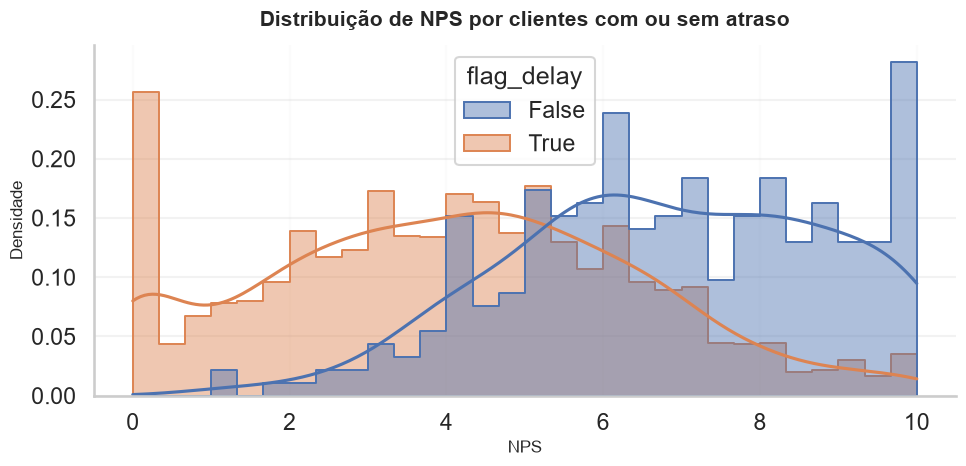

In [5]:
dv.plot_comparative_histogram(
    df,
    value_col="nps_score",
    group_col="flag_delay",
    title="Distribuição de NPS por clientes com ou sem atraso",
    x_label="NPS"
)

Os histogramas dos dois grupos mostra que claramente existe, de fato, uma diferença na distribuição entre clientes com e sem atraso.

Podemos quantificar essa diferença de forma inicial usando medidas de tendência central:

In [14]:
print("Estatísticas descritivas de NPS para grupo de clientes com atraso:")
df.loc[df["flag_delay"] == 1]['nps_score'].describe()

Estatísticas descritivas de NPS para grupo de clientes com atraso:


count    2223.000000
mean        4.069816
std         2.392110
min         0.000000
25%         2.300000
50%         4.100000
75%         5.750000
max        10.000000
Name: nps_score, dtype: float64

In [15]:
print("Estatísticas descritivas de NPS para grupo de clientes sem atraso:")
df.loc[df["flag_delay"] == 0]['nps_score'].describe()

Estatísticas descritivas de NPS para grupo de clientes sem atraso:


count    277.000000
mean       6.856679
std        2.013667
min        1.100000
25%        5.500000
50%        6.800000
75%        8.500000
max       10.000000
Name: nps_score, dtype: float64

É notável que a distribuição de clientes com atraso e sem atraso é significativamente diferente, com valores de média e mediana muito deslocados, corroborando com a hipótese de que o atraso impacta negativamente o NPS.

O grupo de clientes com pelo menos um dia de atraso tem NPS médio de 4,07, enquanto clientes sem atraso em suas entregas tem NPS médio de 6,85. 

Além disso, em ambos os grupos, a mediana se encontra próxima à média, indicando que a média parece ser uma medida representativa da tendência central e que os resultados não aparentam estar fortemente distorcidos por valores extremos

Em seguida, precisamos responder uma pergunta importante para continuar investigando a hipótese:

Existe uma "tolerância" a dias de atraso? Ou o NPS tende a cair de forma linear conforme aumentam os dias de atraso?

Pra isso, podemos usar um gráfico de dispersão com as variáveis de NPS e dias de atraso

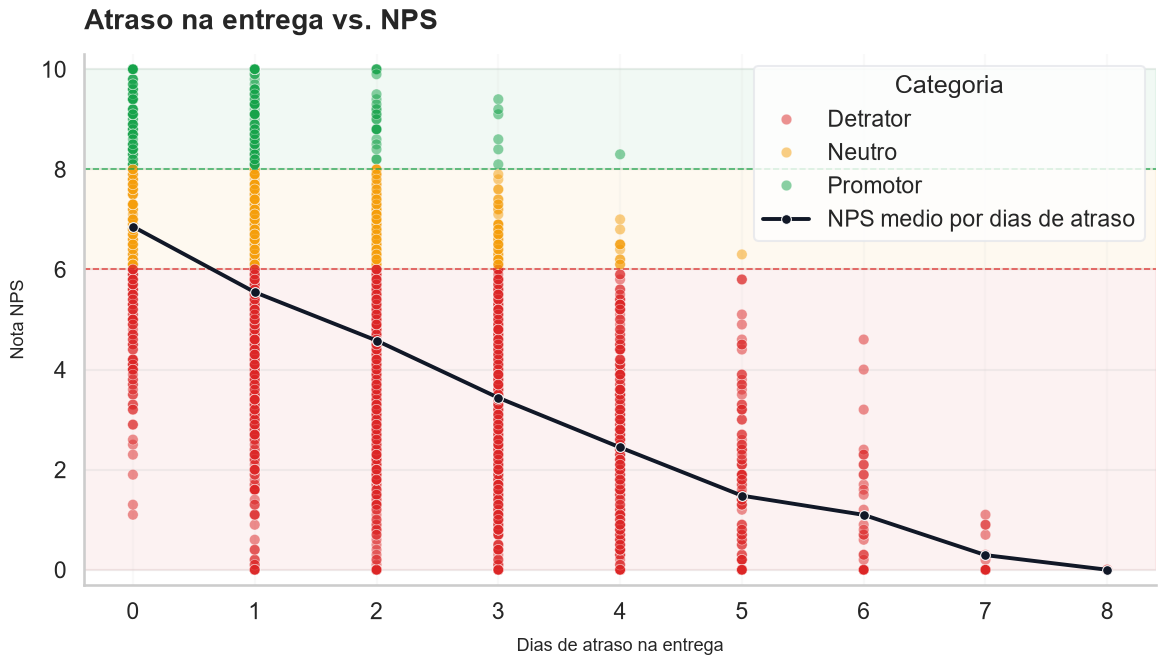

In [4]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="delivery_delay_days",
    title="Atraso na entrega vs. NPS",
    x_label="Dias de atraso na entrega",
    mean_line_label="NPS medio por dias de atraso",
)

Em primeira análise, parece haver uma relação linear negativa entre a quantidade de dias de atraso e o NPS. Essa relação linear, inclusive, parece indicar que não existe um limiar de "tolerância" para atraso, a partir do qual o atraso passa a influenciar MAIS no NPS.

Para verificar essa relação, podemos, além das visualizações geradas anteriormente, calcular a correlação entre dias de atraso e score de NPS. Como verificamos no gráfico de dispersão acima que a relação parece se comportar de forma linear, podemos usar o coeficiente de correlação de Pearson, que tem como premissas: 

- Relação linear entre as variáveis
- Variáveis numéricas
- Não haver predominância de outliers na distribuição das variáveis e em suas medidas de tendência central
- Observações independentes

In [8]:
df[["nps_score", "delivery_delay_days"]].corr(method = 'pearson')

,nps_score,delivery_delay_days
nps_score,1.00000,-0.59726
delivery_delay_days,-0.59726,1.00000


Mais uma vez, por meio do cálculo do coeficiente de correlação, fica claro há evidências de associação entre a quantidade de dias de atraso e o score de NPS, uma vez que a correlação de -0,6 obtida é considerada uma correlação moderada de magnitude relevante, de acordo com o artigo _Correlation Coefficients: Appropriate Use and Interpretation_ de Schober, et. al (2018)

Como um aprofundamento dessa hipótese, podemos tentar entender como é a variação média esperada de NPS associada a cada dia adicional de atraso, usando um modelo simples de regressão. No entanto, o uso desse modelo não deve ser interpretado como efeito causal isolado, já que outras variáveis potencialmente relacionadas à satisfação não foram controladas. Usando um modelo de regressão múltipla, poderíamos, por exemplo, entender como é essa relação se mantivessemos todas as outras variáveis constantes, e, com o auxílio de outras análises, estabelecer uma relação causal mais clara. Esse modelo mais complexo, no entanto, não será abordado durante a presente análise, que tem fins exploratórios. 


In [9]:
# Variáveis da regressão
x_col = "delivery_delay_days"
y_col = "nps_score"

# dataframe só com as colunas necessárias
model_df = df[[x_col, y_col]].dropna().copy()

X = sm.add_constant(model_df[x_col])
y = model_df[y_col]

# Fit de modelo de regressão linear simples de uma variável
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              nps_score   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     1385.
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          1.31e-241
Time:                        14:58:15   Log-Likelihood:                -5296.3
No. Observations:                2500   AIC:                         1.060e+04
Df Residuals:                    2498   BIC:                         1.061e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   6.6332    

In [10]:
intercept = model.params["const"]
coef = model.params[x_col]
r2 = model.rsquared
p_value = model.pvalues[x_col]
conf_int = model.conf_int().loc[x_col]

print(f"Intercepto: {intercept:.3f}")
print(f"Coeficiente de dias de atraso: {coef:.3f}")
print(f"R²: {r2:.3f}")
print(f"p-valor: {p_value:.4f}")
print(f"IC 95% do coeficiente: [{conf_int[0]:.3f}, {conf_int[1]:.3f}]")

Intercepto: 6.633
Coeficiente de delivery_delay_days: -1.031
R²: 0.357
p-valor: 0.0000
IC 95% do coeficiente: [-1.085, -0.977]


Na amostra analisada, o modelo de regressão linear simples indica que cada dia adicional de atraso está associado, em média, a uma redução de 1,03 ponto no score de NPS.

#### Conclusões da hipótese: 

Clientes com ao menos um dia de atraso apresentam em média, um NPS 2.8 pontos menor do que clientes em que não tiveram nenhum dia de atraso.

Além disso, podemos dizer que há associação linear entre as variáveis, corroborada por meio do modelo simples de regressão, bem como do cálculo do coeficiente de correlação entre as variávies de NPS e dias de atraso e da relação visual entre ambas. 

Embora não possamos destacar causalidade direta entre as variáveis a partir dessas análises, podemos concluir que há evidências que apontam que associação negativa entre dias de atraso e NPS, e portanto sustentar a hipótese, sob essas condições. 

### **H2:** Mais tentativas de entrega reduzem NPS.

De forma análoga ao que foi feito em H1, podemos estudar a relação entre as variáveis de quantidade de tentativas de entregas e score NPS, como uma primeira busca por respostas para essa hipótese.

No Sanity Check foi observado que só existem 3 valores distintos para a variável de tentativas de entregas (`delivery_attempts`). Dessa forma, uma visualização de boxplot pode ser mais adequada para identificar essa relação do que um gráfico de dispersão. 

Também podemos verificar as medidas de tendência central.

<string>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



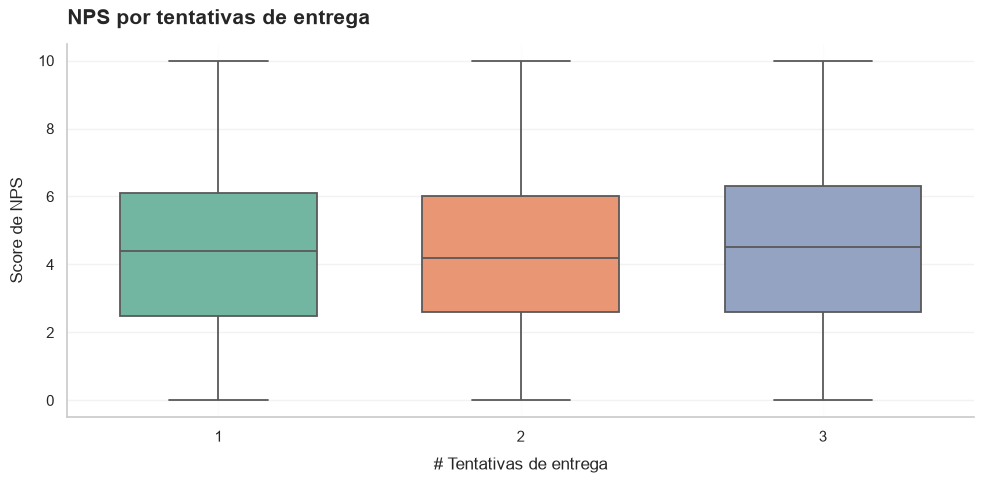

In [24]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="delivery_attempts",
    y_col="nps_score",
    hue_col=None,
    title="NPS por tentativas de entrega",
    x_label="# Tentativas de entrega",
    y_label="Score de NPS",
    legend_title="Categoria NPS",
)

In [25]:
summary = (
    df
    .groupby(["delivery_attempts"])["nps_score"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median"
    )
    .round(2)
    .reset_index()
)

summary

,delivery_attempts,quantidade,media,mediana
0,1,824,4.35,4.4
1,2,838,4.26,4.2
2,3,838,4.52,4.5


Tanto pelo boxplot quanto pelas estatísticas descritivas dos grupos, não parece haver diferença entre eles que indique associação entre a variável de tentativas de entrega e NPS.

Como aprofundamento dessa hipótese, podemos verificar, por exemplo se não há associação entre dias de atraso e quantidade de tentativas de entrega, o que é esperado pelo resultado parcial dessa hipótese e pelo resultado de H1. 

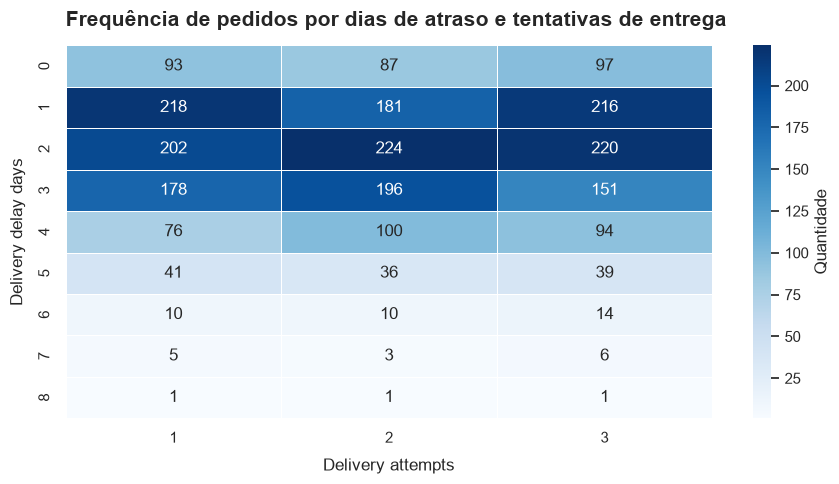

In [34]:
fig, ax = dv.plot_crosstab_heatmap(
    df,
    row_col="delivery_delay_days",
    col_col="delivery_attempts",
    normalize=None,
    title="Frequência de pedidos por dias de atraso e tentativas de entrega",
)

O comportamento mostrou-se conforme o esperado, pelo gráfico acima

#### Conclusões da hipótese:

Não temos evidência suficiente para afirmar que existe associação entre Quantidade de tentativas de entrega e Score de NPS

### **H3:** Tempo total de entrega importa menos que atraso percebido?

Inicialmente, podemos fazer uma verificação do gráfico de dispersão entre as variáveis envolvidas.

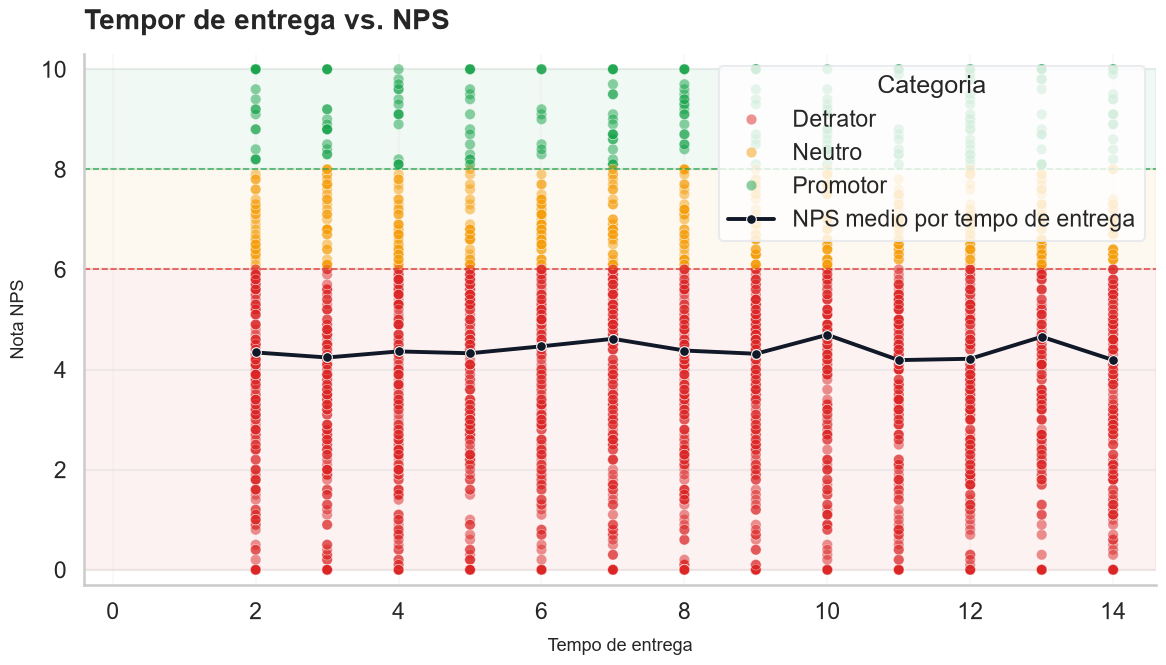

In [36]:
fg, ax = dv.plot_nps_relationship(
    df,
    x_col="delivery_time_days",
    title="Tempor de entrega vs. NPS",
    x_label="Tempo de entrega",
    mean_line_label="NPS medio por tempo de entrega",
)


#### Conclusão da hipótese: 
Apenas por observação do gráfico de dispersão, por observar que não há associação entre tempo de entrega e NPS, e tendo em vista o que foi observado em H1, podemos sustentar a hipótese de que de fato, o tempo total de entrega impacta menos que o atraso percebido na satsifação, tendo o NPS como variável de análise. 

### **H4:** Fretes altos tem associação com NPS

Para uma primeira análise direta dessa hipótese, podemos novamente usar o gráfico de dispersão.

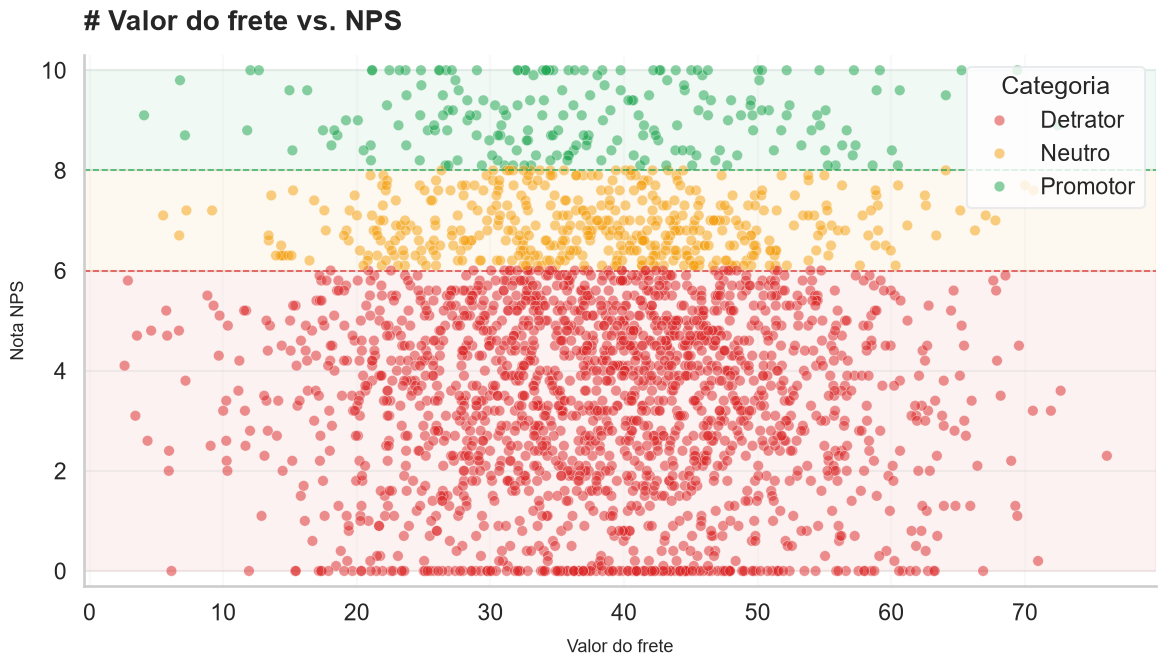

In [43]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="freight_value",
    title="# Valor do frete vs. NPS",
    x_label="Valor do frete",
    show_mean_line=False
)

A primeira vista, utilizando o valor absoluto do frete, não parece haver associação entre as variáveis.

Porém, existem alguns aprofundamentos que podem ser feitos para explorar essa hipótese. 

Um exemplo é fazer uma verificação usando o valor do frete de forma relativa ao valor da compra. Essa feature foi criada na etapa de feature engineering, e está armazenada na coluna `freight_rate`

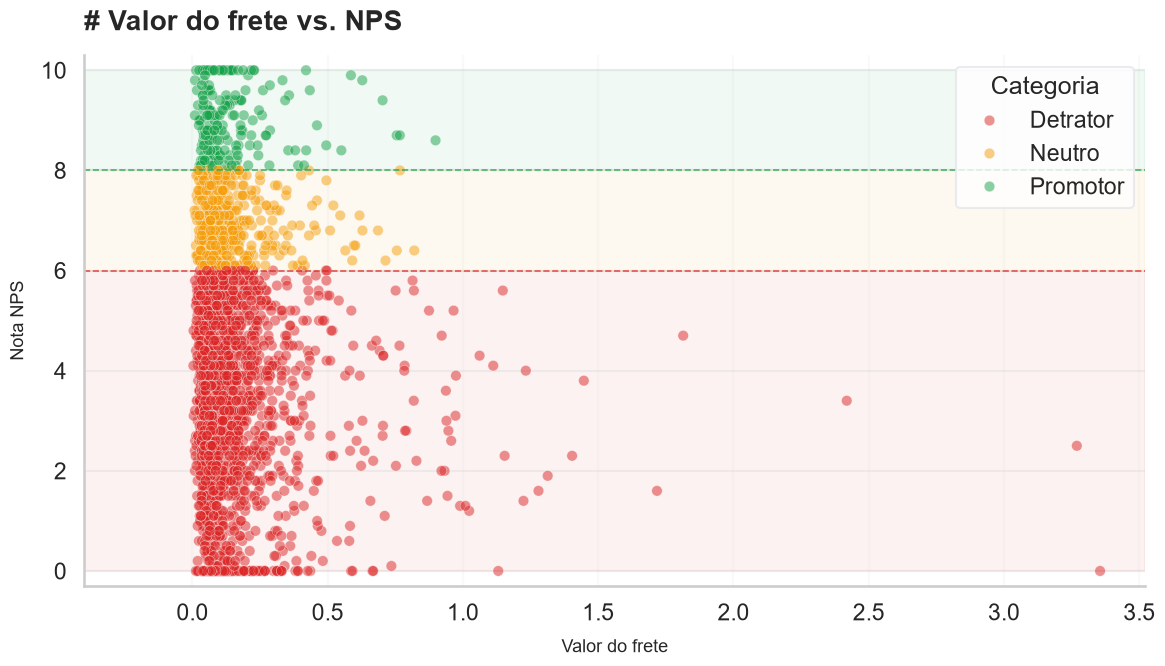

In [45]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="freight_rate",
    title="# Valor do frete vs. NPS",
    x_label="Valor do frete",
    show_mean_line=False
)

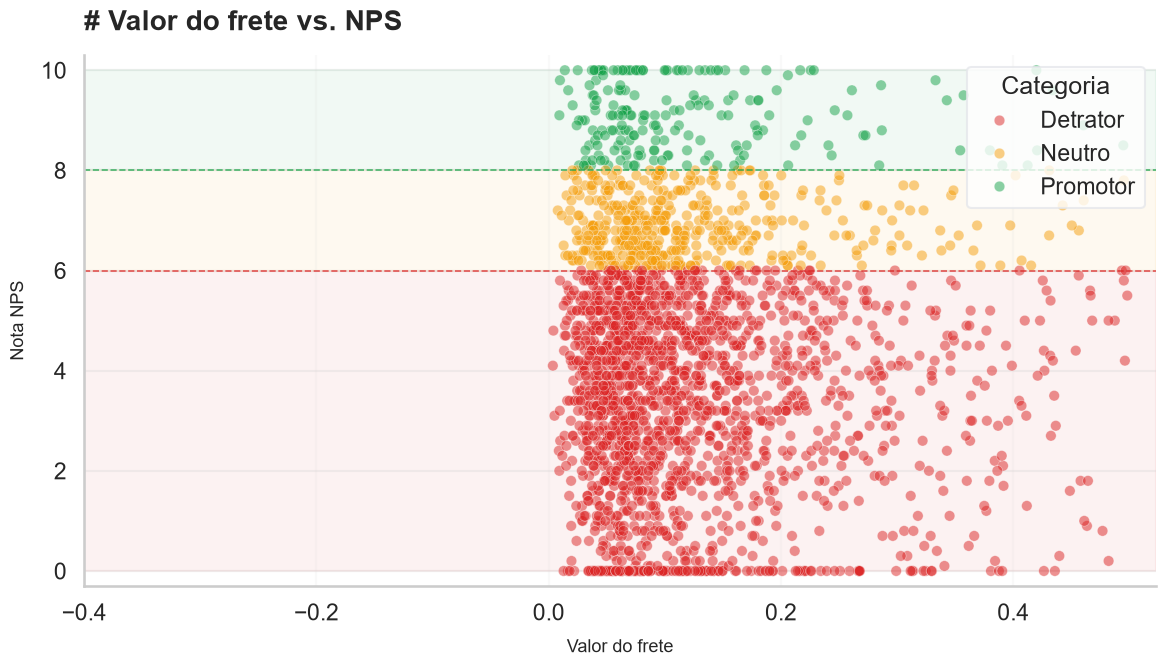

In [46]:
# Verificação em faixa mais comum de valores
fig, ax = dv.plot_nps_relationship(
    df.loc[df["freight_rate"] < 0.5],
    x_col="freight_rate",
    title="# Valor do frete vs. NPS",
    x_label="Valor do frete",
    show_mean_line=False
)

Ainda assim, visualizando de forma relativa, não há evidências para sustentar que existe associação entre o valor do frete e a variável de satisfação analisada

Outro aprofundamento válido é pensar em fazer recortes para entender como o frete combinado com outras variáveis de perfil como faixa etária ou região podem impactar mais no NPS. 

Esses recortes não são obrigatórios para validar a hipótese inicial, mas podem ajudar a entender comportamentos diferentes entre grupos de clientes, considerando a variável do frete.

Como forma de aprofundamento, utilizaram-se 2 variáveis para fazer esse recorte:

- Região do cliente: A depender do negócio, regiões diferentes podem ter variações maiores ou menores de frete, e, clientes dentro de uma região podem ter comportamentos diferentes e percepções de insatisfação diferentes considerando o valor do frete. 
- Faixa etária: Em alguma faixa etária, os clientes podem estar mais suscetíveis a associar fretes caros com insatisfação.

H4.1: Frete x Região x NPS

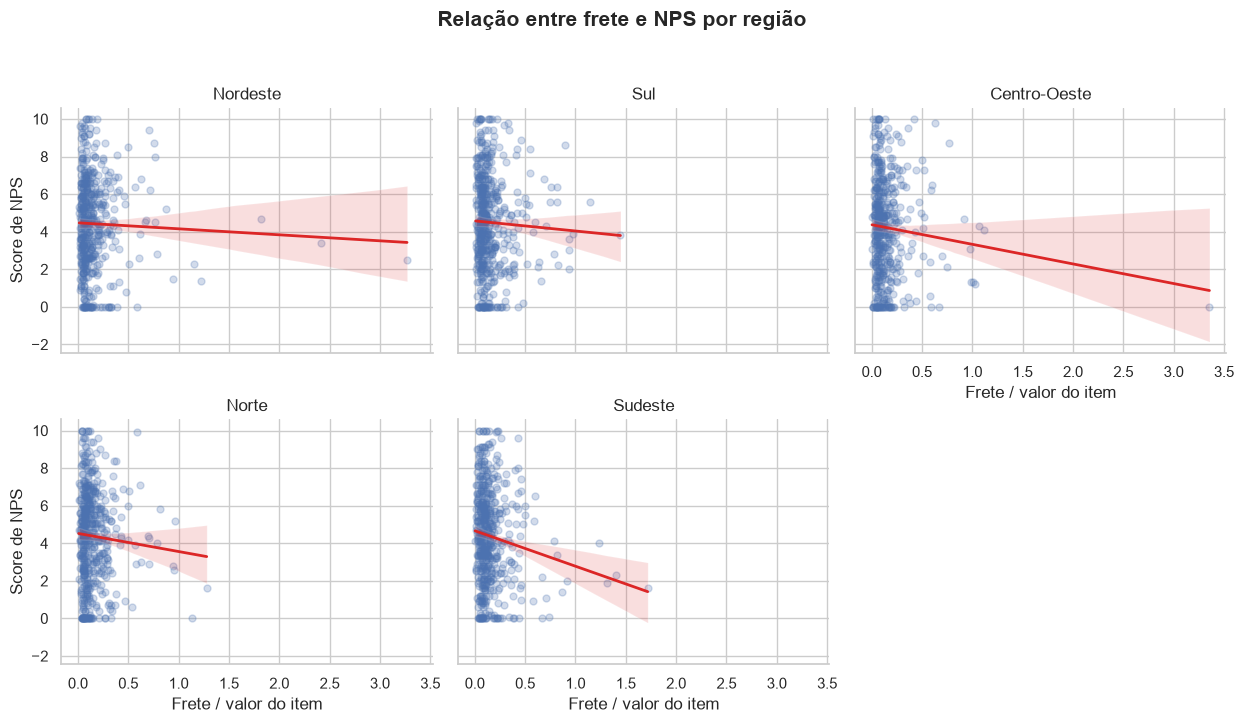

In [55]:
g = dv.plot_faceted_regression(
    df,
    x_col="freight_rate",
    y_col="nps_score",
    facet_col="customer_region",
    title="Relação entre frete e NPS por região",
    x_label="Frete / valor do item",
    y_label="Score de NPS",
)

H4.2. Frete x Faixa Etária x NPS

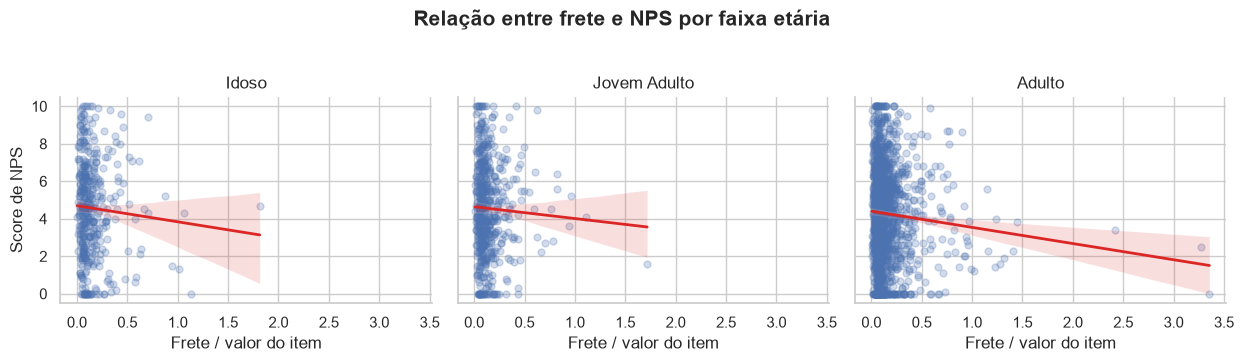

In [57]:
g = dv.plot_faceted_regression(
    df,
    x_col="freight_rate",
    y_col="nps_score",
    facet_col="faixa_etaria",
    title="Relação entre frete e NPS por faixa etária",
    x_label="Frete / valor do item",
    y_label="Score de NPS",
)

Considerando o comportamento observado, não parece haver associação entre NPS e valor do frente em nenhum dos recortes feitos. Os coeficientes das regressões realizados acima são muito influenciados por poucos pontos dispersos e que não devem ser considerados para tirar conclusões, e na faixa em que a maior parte dos valores de taxa de frete estão concentrados, não parece haver associação com NPS.

#### Conclusão da hipótese: 

Não há evidência para sustentar a hipótese de que fretes altos tem associação com NPS

### **H5:** Frete alto + atraso impacta mais no NPS do que somente atraso. 

Essa hipótese pode ser analisada de diferentes formas

Uma forma é considerar, por exemplo, o grupo dos clientes que sofreram com atraso e entender se há diferença entre o NPS daqueles que foram cobrados fretes maiores.

Então, como primeira análise, compara-se o NPS médio dos clientes com atraso com aqueles que, além do atraso, estão entre os 10% maiores fretes do grupo

In [66]:
delay_df = df.loc[df["flag_delay"] == 1].copy()

freight_p90 = delay_df["freight_rate"].quantile(0.9)

delay_df["grupo_frete"] = np.where(
    delay_df["freight_rate"] >= freight_p90,
    "Frete alto (>= P90)",
    "Demais clientes com atraso"
)

print(f"Percentil 90 de freight_rate entre clientes com atraso: {freight_p90:.4f}")

comparacao_grupos = eda.compare_groups(
    delay_df,
    group_col="grupo_frete",
    value_col="nps_score"
)

comparacao_grupos

Percentil 90 de freight_rate entre clientes com atraso: 0.3059


,grupo_frete,count,mean,median,std,min,q1,q3,max
0,Demais clientes com atraso,2000,4.13,4.2,2.39,0.0,2.40,5.80,10.0
1,Frete alto (>= P90),223,3.55,3.5,2.35,0.0,1.75,5.05,9.9


Observando os dois grupos, nota-se uma pequena diferença em media e mediana de NPS, com o grupo que foi cobrado por mais frente com menor NPS. 

Como a diferença é cerca de 0,7 em NPS, em mediana, podemos avaliar o gráfico de dispersão de NPS x taxa de frete somente nos clientes com atraso para aprofundar e tirar melhores conclusões dessa hipótese. 

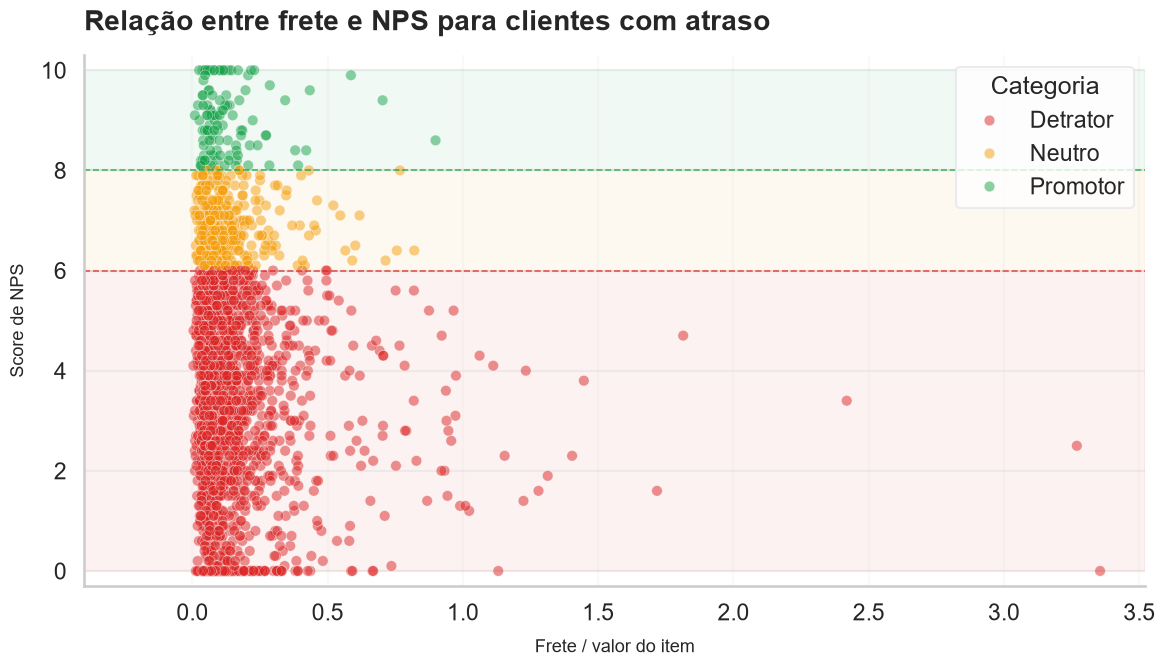

In [69]:
fig, ax = dv.plot_nps_relationship(
    delay_df,
    x_col="freight_rate",
    title = "Relação entre frete e NPS para clientes com atraso",
    x_label="Frete / valor do item",
    y_label="Score de NPS",
    show_mean_line=False) 

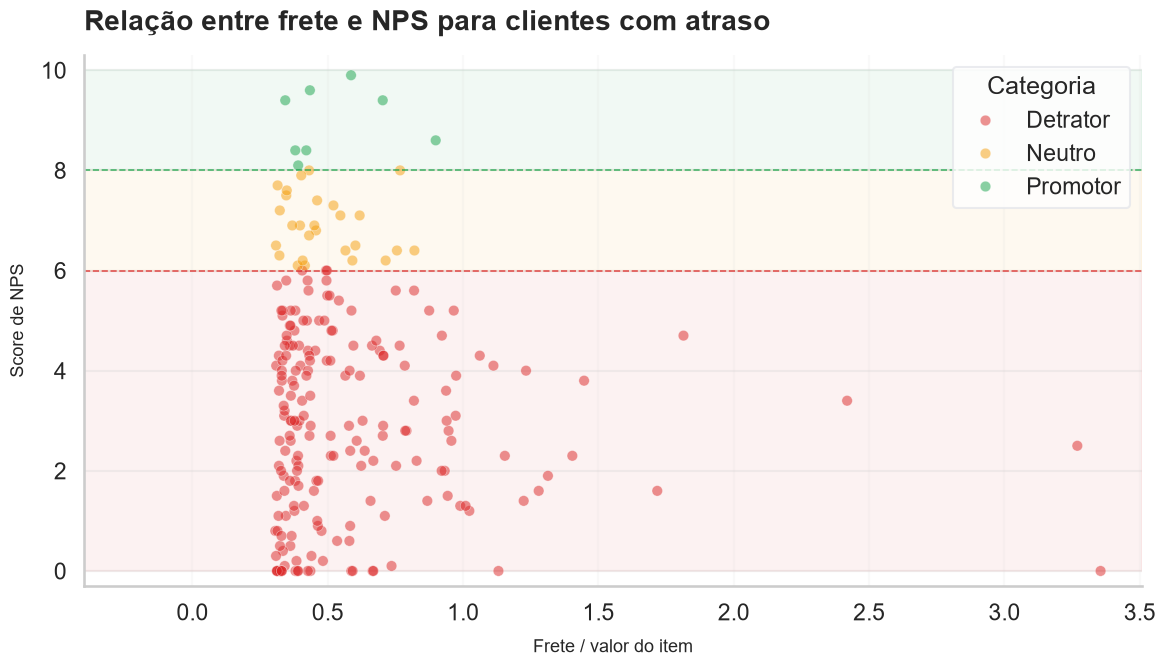

In [68]:
fig, ax = dv.plot_nps_relationship(
    delay_df[delay_df["grupo_frete"] == "Frete alto (>= P90)"],
    x_col="freight_rate",
    title = "Relação entre frete e NPS para clientes com atraso",
    x_label="Frete / valor do item",
    y_label="Score de NPS",
    show_mean_line=False) 

#### Conclusões da hipótese: 

Apesar de haver uma pequena diferença nos valores de tendência central entre o grupo com frente mais caro e os demais clientes com atraso, o gráfico de dispersão mostra que não há associação clara entre frete mais caro e menor NPS no grupo de clientes que tiveram atraso. 

## Resumo de conclusões das hipóteses do Bloco 1 (Logística)

As análises do Bloco 1 indicam que o atraso na entrega é o principal fator logístico associado à queda de satisfação medida pelo NPS.

Na H1, clientes com pelo menos um dia de atraso apresentaram NPS médio de 4,07, contra 6,86 entre clientes sem atraso, uma diferença de aproximadamente 2,8 pontos. Além disso, a correlação entre dias de atraso e NPS foi de -0,60, indicando associação negativa moderada e relevante. 

Na H2, a quantidade de tentativas de entrega não apresentou diferença relevante de NPS entre os grupos. As médias ficaram próximas: 4,35 para uma tentativa, 4,26 para duas e 4,52 para três. Portanto, não há evidências suficientes para sustentar que mais tentativas de entrega estejam associadas a menor NPS.

Na H3, a análise visual sugere que o tempo total de entrega tem associação mais fraca com NPS do que o atraso percebido. Enquanto os dias de atraso apresentaram relação negativa clara com NPS, o tempo total de entrega não mostrou padrão evidente. Assim, a hipótese de que o atraso percebido importa mais do que o tempo total de entrega é sustentada de forma exploratória.

Na H4, não foram encontradas evidências de associação relevante entre frete alto e NPS, seja considerando o valor absoluto do frete, a proporção do frete sobre o valor do item (`freight_rate`) ou recortes por região e faixa etária. Os padrões observados parecem ser influenciados por poucos pontos dispersos, sem tendência consistente na faixa onde a maior parte dos dados se concentra. Portanto, a hipótese de que fretes altos têm associação direta com NPS não é sustentada.

Na H5, considerando apenas clientes com atraso, o grupo com frete alto, definido como `freight_rate` acima do percentil 90%, apresentou NPS médio de 3,55, enquanto os demais clientes com atraso apresentaram média de 4,13. A diferença existe, mas é relativamente pequena frente ao impacto observado na H1 para atraso em si. Além disso, a análise do gráfico de dispersão não permite afirmar que há associação entre frete e NPS nesse grupo de clientes com atraso

## Bloco 2:
### Impacto do atendimento na satisfação

- **H6:** Mais contatos com atendimento indicam maior chance de detrator/menor NPS
- **H7:** Maior tempo de resolutividade reduz NPS.
- **H8:** Reclamacoes sao mais impactantes em NPS que contatos simples.
- **H9:** Atendimento rapido pode recuperar parcialmente clientes com problema logistico. 

### **H6:** Mais contatos com atendimento indicam maior chance de detrator/menor NPS

Para verificar essa hipótese, podemos primeiro checar o percentual de promotores conforme aumenta-se a quantidade de contatos (`customer_service_contacts`), e, em seguida, examinar a relação com o NPS score de fato.

In [20]:
df_grouped_csc = df.groupby("customer_service_contacts")["classificacao"].value_counts(normalize=True).unstack().fillna(0).reset_index()

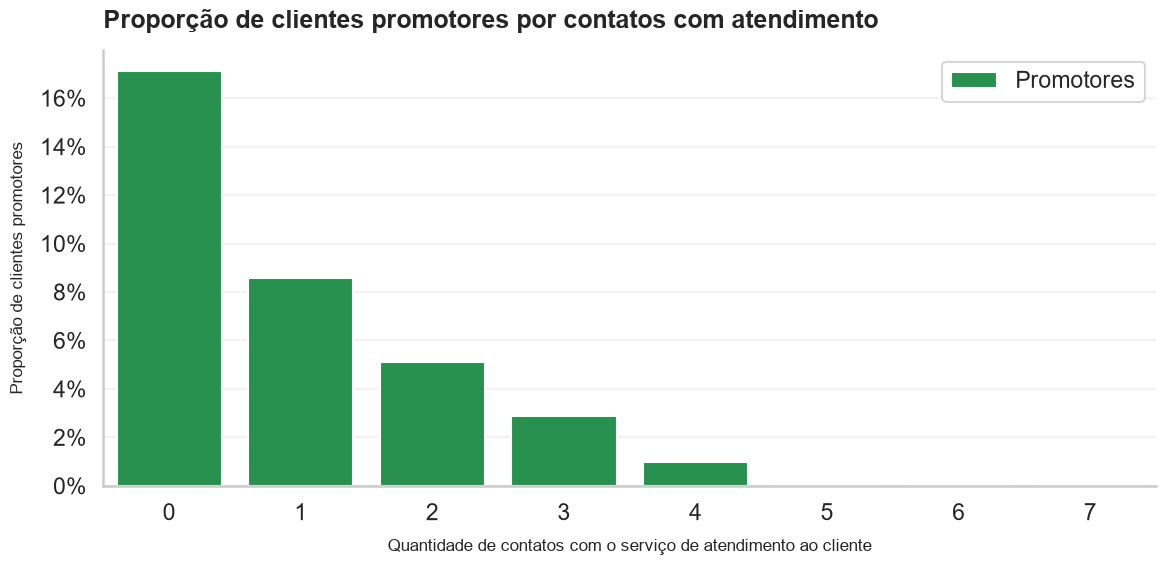

In [27]:
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_grouped_csc,
    x="customer_service_contacts",
    y="Promotor",
    color="#16A34A",
    label="Promotores",
    ax=ax,
)

ax.set_title(
    "Proporção de clientes promotores por contatos com atendimento",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=16,
)

ax.set_xlabel(
    "Quantidade de contatos com o serviço de atendimento ao cliente",
    fontsize=12,
    labelpad=10,
)

ax.set_ylabel(
    "Proporção de clientes promotores",
    fontsize=12,
    labelpad=10,
)

ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

sns.despine()
plt.tight_layout()

Observa-se que a partir de 5 contatos, não existem mais promotores. Além disso, vemos que conforme aumenta a quantidade de contatos, o percentual de clientes promotores decresce. 

Isso são bons indícios para sustentarmos a hipótese. Na sequência, vamos análiser a dispersão entre as variáveis de #contatos com NPS score para aprofundar o entendimento do comportamento

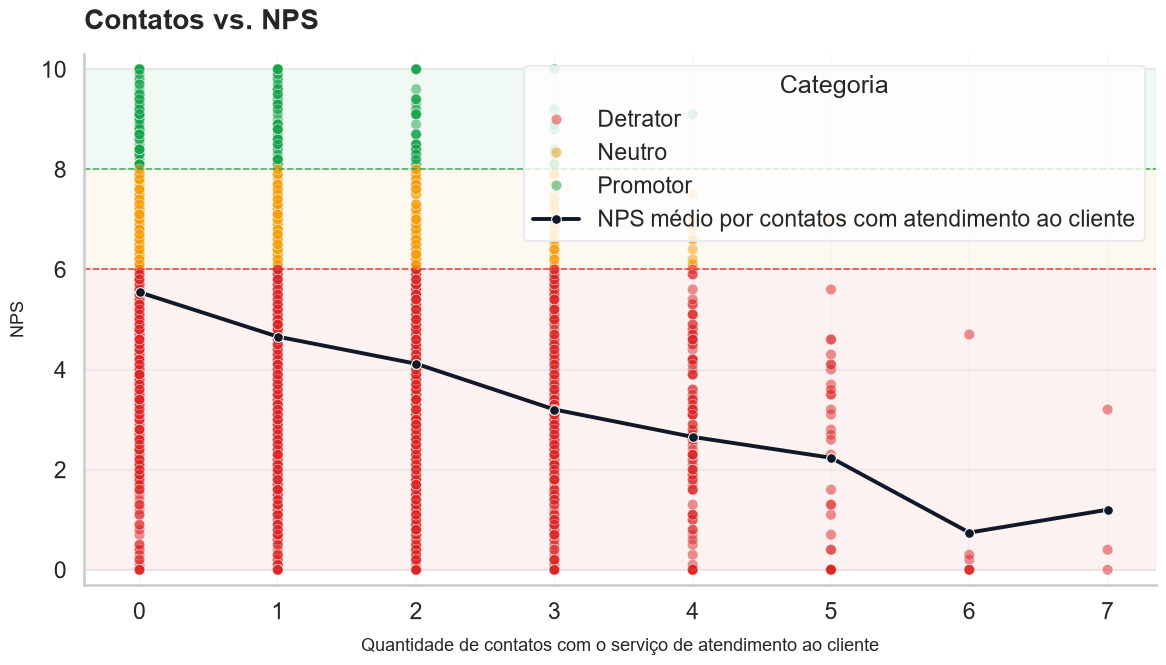

In [28]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="customer_service_contacts",
    title="Contatos vs. NPS",
    x_label="Quantidade de contatos com o serviço de atendimento ao cliente",
    mean_line_label="NPS médio por contatos com atendimento ao cliente",
    y_label="NPS")

In [29]:
df[["nps_score", "customer_service_contacts"]].corr(method = 'pearson')

,nps_score,customer_service_contacts
nps_score,1.000000,-0.350845
customer_service_contacts,-0.350845,1.000000


Observando a dispersão e o coeficiente de correlação, vemos uma relação aproximadamente linear entre as duas variáveis, mostrando associação entre o aumento da quantidade de contatos com o serviço de atendimento ao cliente e a redução no NPS score, corroborando com os achados verificados anteriormente. 

Essa correlação, no entanto, é mais fraca do que a que foi verificada para a quantidade de dias de atraso, por exemplo, na Hipótese H1.

#### Conclusões da hipótese

Após as análises, temos evidências para sustentar a hipótese de que há associação entre a quantidade de contatos com o serviço de atendimento ao cliente. Essa relação ainda se mostrou linear, conforme verificado na dispersão. 

Vale ressaltar 2 pontos:
- A partir de 5 atendimentos, não há mais promotores na amostra analisada;
- A correlação existe, mas é de magnitude fraca-moderada.

### **H7:** Maior tempo de resolutividade reduz NPS.

Essa hipótese visa analisar se o aumento do tempo de resolutividade de um atendimento tem associação com o NPS. 

Para uma primeira visualização, novamente iremos utilizar um gráfico de dispersão, seguido de um cálculo de correlação.

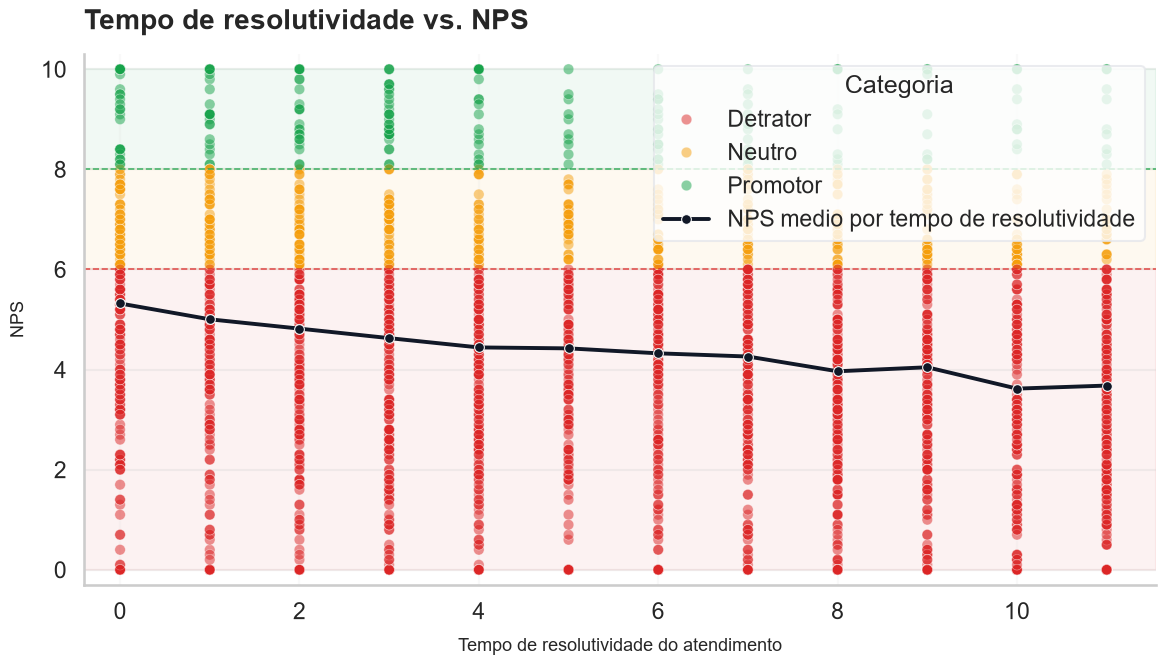

In [33]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="resolution_time_days",
    title="Tempo de resolutividade vs. NPS",
    x_label="Tempo de resolutividade do atendimento",
    mean_line_label="NPS medio por tempo de resolutividade",
    y_label="NPS")


In [32]:
df[["nps_score", "resolution_time_days"]].corr(method = 'pearson')

,nps_score,resolution_time_days
nps_score,1.000000,-0.191392
resolution_time_days,-0.191392,1.000000


Somente pelo gráfico de dispersão, não parece haver associação entre as variáveis. No entanto, ao calcular a média de NPS por tempo de resolutividade, nota-se um pequeno decréscimo no NPS conforme aumenta o tempo de resolutividade, o que é corroborado pelo coeficiente de correlação negativo e de baixa magnitude calculado posteriormente. 

#### Conclusões da hipótese: 

Há um pequeno decréscimo em média de NPS conforme aumenta o tempo de resolutividade, denotado por uma correlação fraca. 

Negocialmente, faria sentido que o NPS decaísse com essa variável. Apesar disso, pelos resultados observados, sugere-se um melhor entendimento negocial da variável de tempo de resolutividade. Por exemplo, é possível que clientes com um tempo de resolutividade alto ainda encarem o problema como "resolvido" e, por isso, essa variável não está fortemente associada ao NPS.

Para fins da presente análise, podemos considerar que a associação observada não é forte o suficiente para evidenciarmos e sustentarmos a hipótese de que, sozinho, o tempo de resolutividade impacta no NPS. No entanto, pode ser interessante observar se essa variável combinada com outras, como por exemplo a quantidade de reclamações, produz resultados mais conclusivos.

### **H8:** Reclamacoes são mais impactantes em NPS que contatos simples.

Antes de tudo, vamos observar se há associação entre NPS e quantidade de reclamações, usando a variável `complaints_count` e um gráfico de dispersão

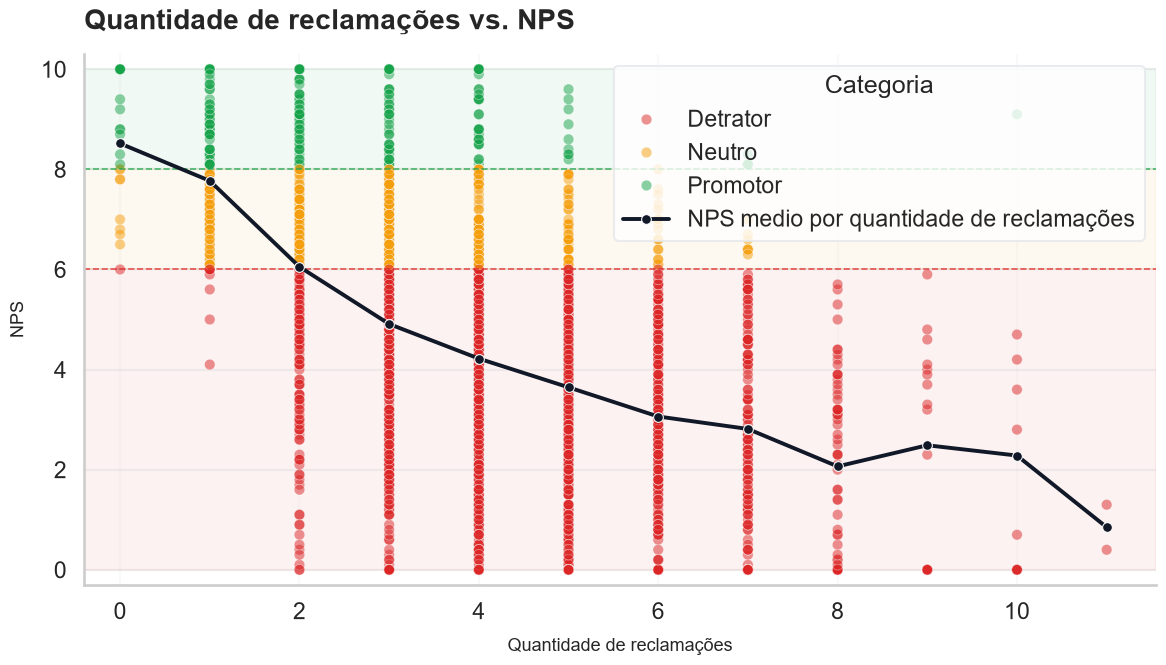

In [37]:
fig, ax = dv.plot_nps_relationship(df,
    x_col="complaints_count",
    title="Quantidade de reclamações vs. NPS",
    x_label="Quantidade de reclamações",
    mean_line_label="NPS medio por quantidade de reclamações",
    y_label="NPS")

Agora sim, podemos observar uma associação praticamente linear e visualmente significativa entre quantidade de reclamações e NPS. Também notamos que a partir 8 reclamações, praticamente não existem mais clientes promotores.

Vamos agora calcular a correlação entre quantidade de reclamações e NPS para reforçar a nossa hipótese de que reclamações são mais associadas a redução no NPS do que quantidade de atendimentos ao cliente.

In [38]:
df[["nps_score", "complaints_count"]].corr(method = 'pearson')

,nps_score,complaints_count
nps_score,1.0000,-0.4968
complaints_count,-0.4968,1.0000


Temos uma correlação de -0.5 entre NPS e quantidade de reclamações e -0.35 entre NPS e quantidade de atendimentos. Isso corrobora que de fato a associação é maior e podemos sustentar nossa hipótese. 

Uma análise importante a ser feita aqui é se existe correlação entre quantidade de atendimentos e quantidade de reclamações, pois, se houver uma correlação alta, usar ambas as variáveis sem tratamento como features em um modelo de regressão pode introduzir multicolinearidade. 

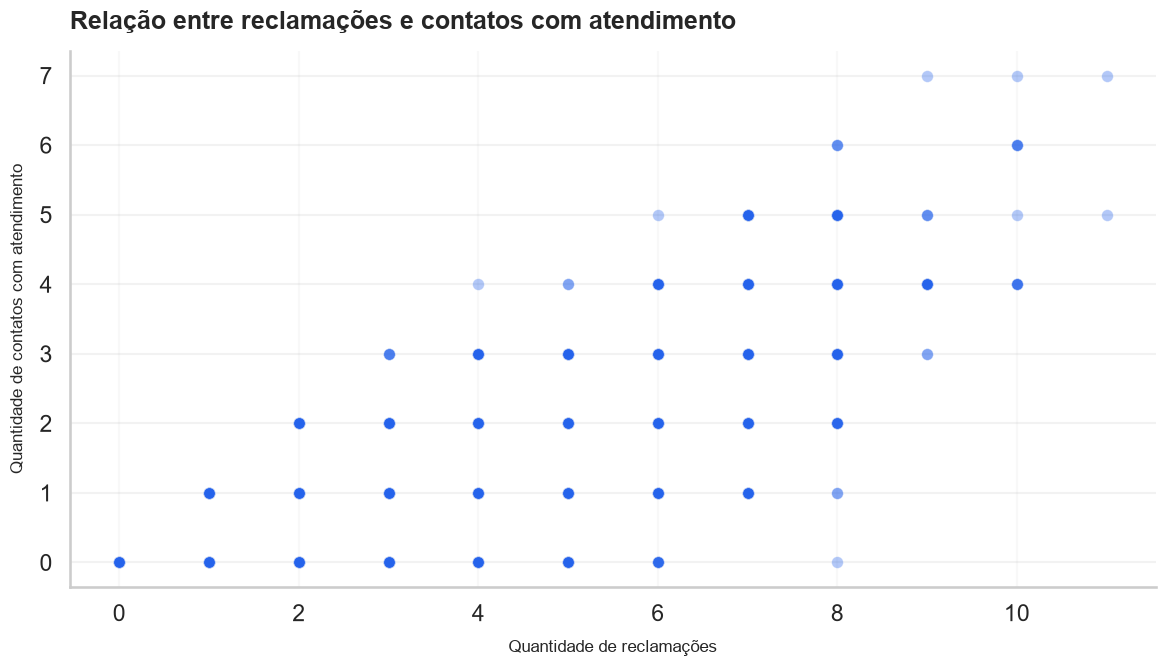

In [43]:
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="complaints_count",
    y="customer_service_contacts",
    alpha=0.35,
    s=70,
    color="#2563EB",
    edgecolor="white",
    linewidth=0.5,
    ax=ax,
)

ax.set_title(
    "Relação entre reclamações e contatos com atendimento",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=16,
)

ax.set_xlabel(
    "Quantidade de reclamações",
    fontsize=12,
    labelpad=10,
)

ax.set_ylabel(
    "Quantidade de contatos com atendimento",
    fontsize=12,
    labelpad=10,
)

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", alpha=0.12)

sns.despine()
plt.tight_layout()

In [44]:
df[["customer_service_contacts", "complaints_count"]].corr(method = 'pearson')

,customer_service_contacts,complaints_count
customer_service_contacts,1.000000,0.754617
complaints_count,0.754617,1.000000


Como esperado, as variáveis de quantidade de reclamações e quantidade de contatos com o serviço de atendimento ao cliente estão altamente correlacionados, e isso é um ponto de atenção pensando em modelagem.

#### Conclusão da hipótese

A análise sustenta a hipótese de que a quantidade de reclamações está mais fortemente associada à queda do NPS do que a quantidade de contatos simples com o atendimento.

Enquanto `customer_service_contacts` apresenta correlação negativa moderada com o NPS, `complaints_count` apresenta uma associação negativa mais forte e um padrão visual mais claro: conforme o número de reclamações aumenta, o NPS médio tende a cair de forma consistente. Além disso, observa-se uma concentração crescente de clientes detratores nos grupos com maior quantidade de reclamações.

Esse resultado faz sentido do ponto de vista de negócio, pois nem todo contato com atendimento representa necessariamente uma experiência negativa. Um cliente pode entrar em contato para tirar dúvidas, acompanhar pedidos ou resolver questões simples. Já uma reclamação indica uma fricção mais explícita na jornada, o que tende a refletir maior insatisfação.

Também foi observado que `complaints_count` e `customer_service_contacts` são altamente correlacionadas. Isso é um ponto de atenção para etapas futuras de modelagem, especialmente em modelos lineares, pois o uso simultâneo das duas variáveis pode introduzir multicolinearidade. Ainda assim, para fins exploratórios, a análise indica que reclamações são um sinal mais forte de insatisfação do que contatos simples com o atendimento.

### **H9:** Atendimento rápido pode recuperar parcialmente clientes com problema logístico. 

Essa é uma hipótese interessante e podemos abordá-la de diferentes formas.

Vamos tentar entender se clientes com atraso, mas com baixo tempo de resolutividade tem um NPS médio maior do que aqueles com atraso, porém tempo de resolutividade alto.

In [46]:
delay_df = df.loc[df["flag_delay"] == True].copy()

resolution_median = delay_df["resolution_time_days"].median()

delay_df["grupo_tempo_resolucao"] = np.where(
    delay_df["resolution_time_days"] <= resolution_median,
    "Atraso + baixo tempo de resolucao",
    "Atraso + alto tempo de resolucao"
)

comparacao_tempo_resolucao = (
    delay_df
    .groupby("grupo_tempo_resolucao")
    .agg(
        qtd_pedidos=("order_id", "count"),
        tempo_resolucao_medio=("resolution_time_days", "mean"),
        nps_medio=("nps_score", "mean"),
        nps_mediano=("nps_score", "median"),
        pct_detratores=("classificacao", lambda s: (s == "Detrator").mean() * 100),
        pct_promotores=("classificacao", lambda s: (s == "Promotor").mean() * 100),
    )
    .round(2)
)

print(f"Mediana de tempo de resolucao entre clientes com atraso: {resolution_median:.2f} dias")

comparacao_tempo_resolucao

Mediana de tempo de resolucao entre clientes com atraso: 5.00 dias


,qtd_pedidos,tempo_resolucao_medio,nps_medio,nps_mediano,pct_detratores,pct_promotores
grupo_tempo_resolucao,,,,,,
Atraso + alto tempo de resolucao,1105,8.51,3.66,3.6,74.84,3.26
Atraso + baixo tempo de resolucao,1118,2.44,4.47,4.5,68.43,7.07


Usando a mediana do tempo de resolutividade como ponto de corte para separar dois grupos (baixo e alto tempo de resolutividade), vemos que os clientes com problema logístico e baixo tempo de resolutividade tem um NPS médio e mediano cerca de 0,9 maior do que os clientes com alto tempo de resolutividade. 

Vamos aplicar pontos de corte diferentes, para dividir em mais grupos e verificar se essa relação se mantem. 

In [47]:
import pandas as pd

delay_df = df.loc[df["flag_delay"] == True].copy()

delay_df["faixa_tempo_resolucao"] = pd.qcut(
    delay_df["resolution_time_days"],
    q=4,
    labels=[
        "Q1 - menor tempo",
        "Q2",
        "Q3",
        "Q4 - maior tempo",
    ],
    duplicates="drop"
)

comparacao_faixas_resolucao = (
    delay_df
    .groupby("faixa_tempo_resolucao", observed=True)
    .agg(
        qtd_pedidos=("order_id", "count"),
        tempo_resolucao_min=("resolution_time_days", "min"),
        tempo_resolucao_medio=("resolution_time_days", "mean"),
        tempo_resolucao_max=("resolution_time_days", "max"),
        nps_medio=("nps_score", "mean"),
        nps_mediano=("nps_score", "median"),
        pct_detratores=("classificacao", lambda s: (s == "Detrator").mean() * 100),
        pct_promotores=("classificacao", lambda s: (s == "Promotor").mean() * 100),
    )
    .round(2)
)

comparacao_faixas_resolucao

,qtd_pedidos,tempo_resolucao_min,tempo_resolucao_medio,tempo_resolucao_max,nps_medio,nps_mediano,pct_detratores,pct_promotores
faixa_tempo_resolucao,,,,,,,,
Q1 - menor tempo,565,0,1.02,2,4.75,4.9,64.07,8.14
Q2,553,3,3.90,5,4.19,4.2,72.88,5.97
Q3,561,6,7.05,8,3.83,3.9,73.44,3.74
Q4 - maior tempo,544,9,10.02,11,3.49,3.4,76.29,2.76


Usando os quartis como ponto de corte, vemos que a relação se mantém, corroborando com nossa hipótese.

#### Conclusão da hipótese

A análise sustenta a hipótese de que um atendimento mais rápido pode recuperar parcialmente a satisfação de clientes que tiveram problema logístico.

Ao considerar apenas clientes com atraso na entrega, observamos que o grupo com baixo tempo de resolução apresentou NPS médio de 4,47, enquanto o grupo com alto tempo de resolução apresentou NPS médio de 3,66. A diferença também aparece na mediana, com 4,5 para o grupo de resolução mais rápida contra 3,6 para o grupo de resolução mais lenta.

Ao dividir o tempo de resolução em quartis, a relação se mantém de forma consistente: o grupo com menor tempo de resolução apresentou NPS médio de 4,75, enquanto o grupo com maior tempo de resolução apresentou NPS médio de 3,49. Além disso, a proporção de promotores cai de 8,14% no grupo de resolução mais rápida para 2,76% no grupo de resolução mais lenta.

Do ponto de vista de negócio, isso sugere que o atraso na entrega continua sendo um fator crítico de insatisfação, mas a atuação do atendimento pode reduzir parte do dano na experiência do cliente. Ou seja, mesmo quando o problema logístico já ocorreu, resolver rapidamente a demanda do cliente parece estar associado a uma percepção menos negativa da jornada.

Portanto, a hipótese é sustentada de forma exploratória: atendimento rápido não elimina o impacto do atraso, mas pode funcionar como mecanismo de recuperação parcial da satisfação.

## Bloco 3
## 3. Perfil do pedido impacta a satisfação?

- **H10:** Pedidos de maior valor geram maior expectativa e menor tolerancia a falhas - Ou seja, pedidos de maiores valores tem menor NPS quando atrasados, por exemplo, em comparação com a média
- **H11:** Maior quantidade de itens aumenta risco operacional (Atrasos, por exemplo)
- **H12:** Descontos reduzem insatisfaçãoo ou mascaram possíveis problemas.
- **H13:** Muitas parcelas podem estar associadas a perfis com comportamento diferente.

### **H10:** Pedidos de maior valor geram maior expectativa e menor tolerancia a falhas - Ou seja, pedidos de maiores valores tem menor NPS quando atrasados, por exemplo, em comparação com a média

Inicialmente, vamos considerar somente os clientes com atraso para análise da expectativa gerada pelo valor. 
Dessa forma, podemos entender se quando há um problema logístico - nesse caso, atraso - temos comportamentos diferentes em termos de NPS em pedidos de maior valor.

In [50]:
df_delay = df.loc[df["flag_delay"] == True].copy()

Para esse grupo, vamos analisar a variação de NPS com preço do pedido

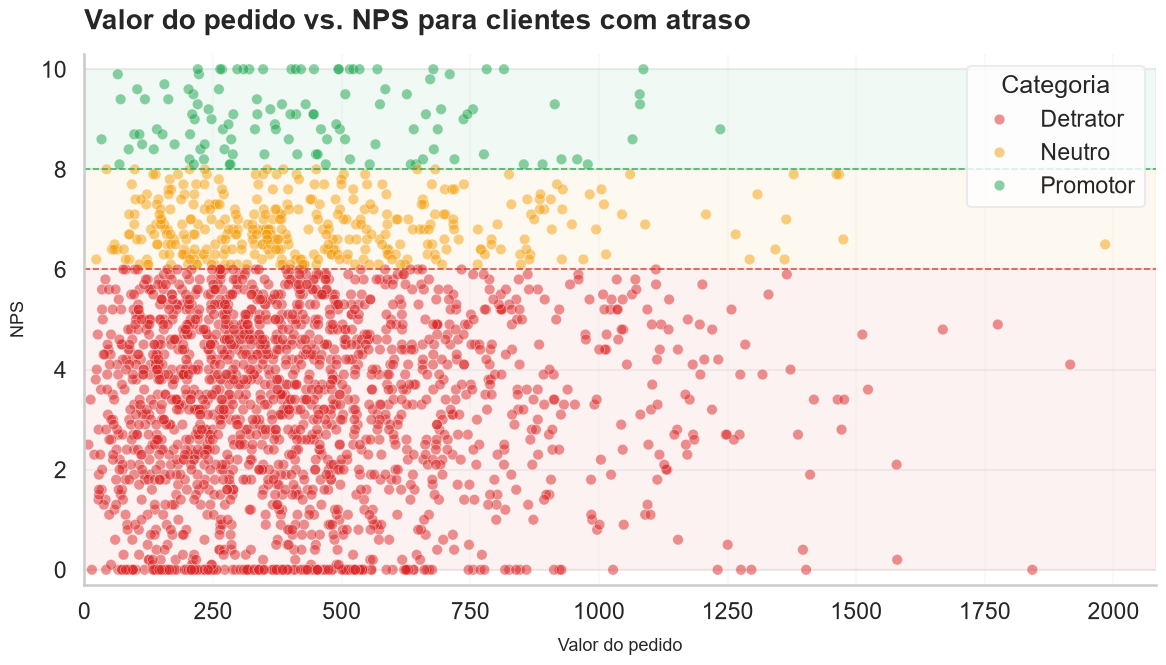

In [54]:
fig,ax = dv.plot_nps_relationship(
    df_delay,
    x_col="order_value",
    title="Valor do pedido vs. NPS para clientes com atraso",
    x_label="Valor do pedido",
    show_mean_line=False,
    y_label="NPS"
)

A princípio, sem fazer nenhum recorte adicional, não parece haver associação entre valor do pedido e NPS em pedidos com atraso. 

Podemos, por exemplo, considerar os pedidos mais atrasados que a média, por exemplo, para analisar por outra perspectiva.

In [62]:
media_dias_atraso = df_delay['delivery_delay_days'].mean()

df_delay_above_avg = df_delay.loc[df_delay['delivery_delay_days'] > media_dias_atraso].copy()

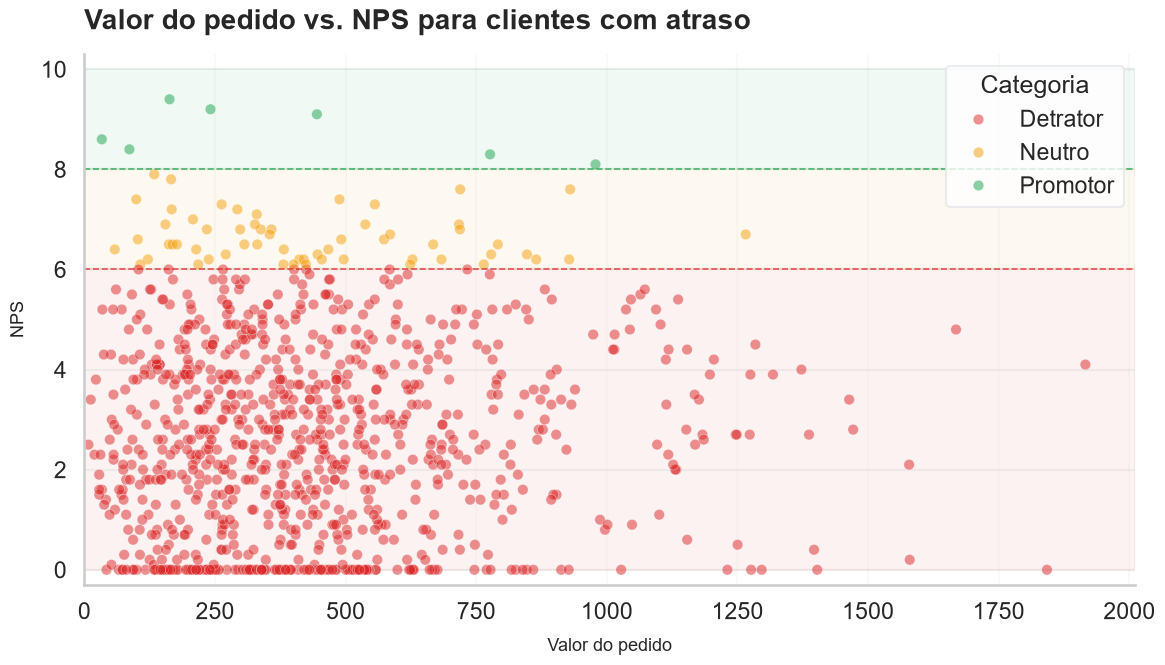

In [63]:
fig,ax = dv.plot_nps_relationship(
    df_delay_above_avg,
    x_col="order_value",
    title="Valor do pedido vs. NPS para clientes com atraso",
    x_label="Valor do pedido",
    show_mean_line=False,
    y_label="NPS"
)

Ainda assim, parece não haver a associação esperada.

### Conclusões da hipótese

Sob os recortes analisados, não há evidências para sustentar que pedidos de maior valor tem associação com menor NPS quando atrasados.

### **H11:** Maior quantidade de itens aumenta risco operacional (Atrasos, por exemplo)

Essa análise é direta, e podemos entender se, ao aumentar a quantidade de itens no pedido, temos uma alteração na distribuição da quantidade de dias de atraso

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


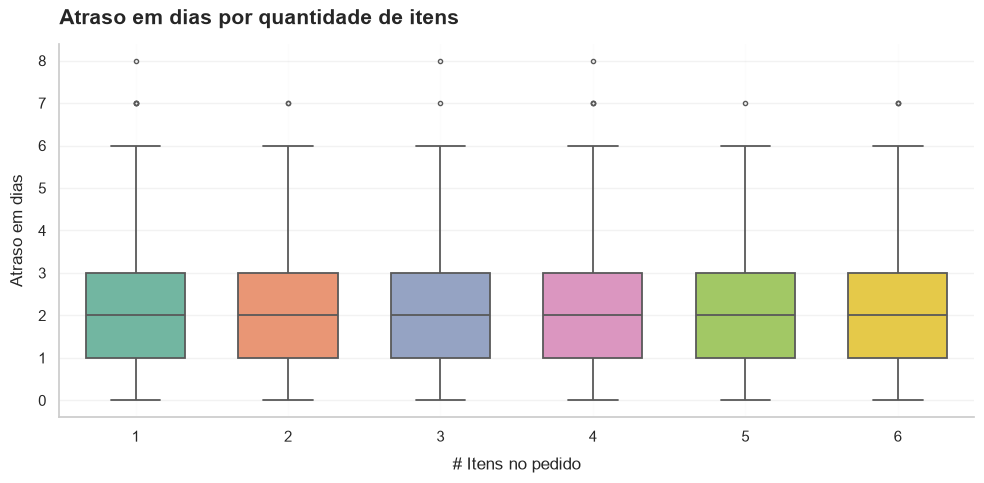

In [71]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="items_quantity",
    y_col="delivery_delay_days",
    hue_col=None,
    title="Atraso em dias por quantidade de itens",
    x_label="# Itens no pedido",
    y_label="Atraso em dias"
)

#### Conclusões da Hipótese

A partir de análise direta do boxplot acima, vemos que não há qualquer alteração significativa na distribuição da quantidade de dias de atraso ao varias a quantidade de itens no pedido

### **H12:** Descontos reduzem insatisfação ou mascaram possíveis problemas.

Como uma primeira análise, podemos ver se o comportamento entre percentual de desconto aplicado no pedido e NPS score denota associação:

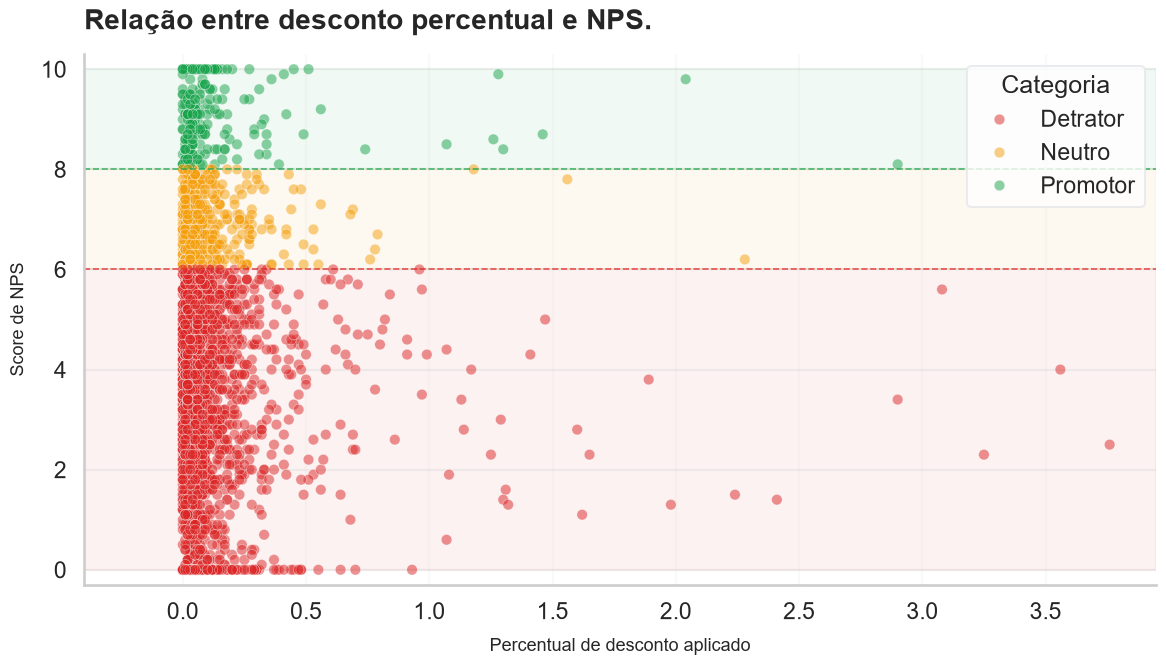

In [77]:
fig, ax = dv.plot_nps_relationship(
    df,
    x_col="pct_desconto",
    title = "Relação entre desconto percentual e NPS.",
    x_label="Percentual de desconto aplicado",
    y_label="Score de NPS",
    show_mean_line=False) 

O gráfico de dispersão acima não indica haver correlação alta entre as variáveis

Um aprofundamento dessa hipótese pode ser avaliar se, conforme o desconto aumenta, há uma redução na quantidade de reclamações, por exemplo.

Para fazer isso, podemos dividir os produtos em quartis de desconto e verificar as diferenças em média e mediana na quantidade de reclamação 

In [78]:
df_discount = df.copy()

df_discount["faixa_desconto"] = pd.qcut(
    df_discount["pct_desconto"],
    q=4,
    labels=[
        "Q1 - menor desconto",
        "Q2",
        "Q3",
        "Q4 - maior desconto",
    ],
    duplicates="drop"
)

comparacao_desconto_reclamacoes = (
    df_discount
    .groupby("faixa_desconto", observed=True)
    .agg(
        qtd_pedidos=("order_id", "count"),
        desconto_medio=("pct_desconto", "mean"),
        reclamacoes_media=("complaints_count", "mean"),
        reclamacoes_mediana=("complaints_count", "median"),
        nps_medio=("nps_score", "mean"),
    )
    .round(2)
)

comparacao_desconto_reclamacoes

,qtd_pedidos,desconto_medio,reclamacoes_media,reclamacoes_mediana,nps_medio
faixa_desconto,,,,,
Q1 - menor desconto,702,0.01,4.15,4.0,4.40
Q2,648,0.04,4.14,4.0,4.48
Q3,548,0.09,4.18,4.0,4.28
Q4 - maior desconto,602,0.37,4.13,4.0,4.33


#### Conclusões da hipótese

A partir dos recortes realizados, podemos afirmar que pedidos com diferentes níveis de desconto não alteram significativamente a distribuição de quantidade de reclamações, além de não haver associação clara entre o percentual de desconto e o Score de NPS. 

Dado isso, não temos evidência para suportar que o percentual de desconto mascara os problemas, dentro do escopo analisado (queda de NPS e quantidade de reclamações).

### **H13:** Muitas parcelas podem estar associadas a perfis com comportamento diferente.

Podemos analisar essa hipótese sob a perspectiva de diferentes variáveis para definir perfis de comportamento. 

Inicialmente, vamos verificar como é o comportamento em relação a nossa variável alvo: NPS score

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


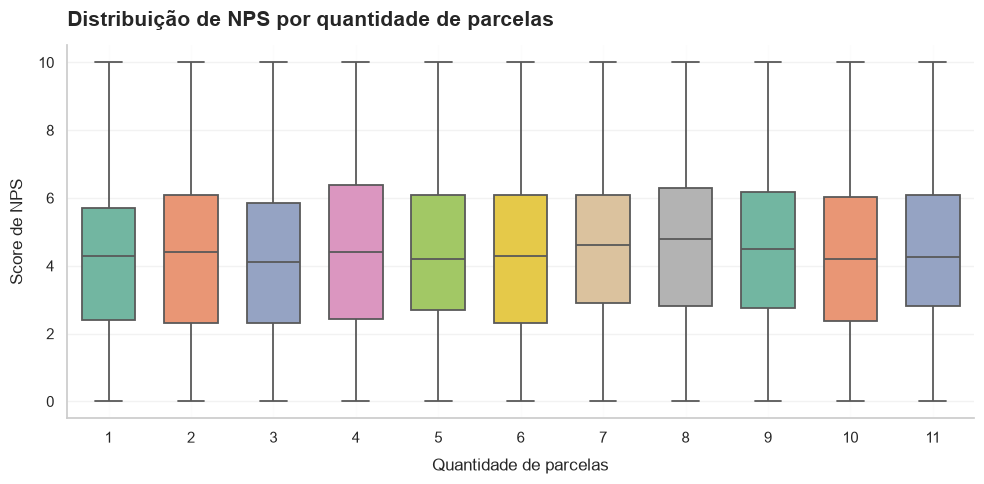

In [79]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="payment_installments",
    y_col="nps_score",
    title="Distribuição de NPS por quantidade de parcelas",
    x_label="Quantidade de parcelas",
    y_label="Score de NPS",
)

Analisando o boxplot acima, vemos que a distribuição de NPS para clientes com diferentes quantidades de parcelas é similar e não apresentam associação direta.

Na sequência, vamos analisar esse comportamento com outras variáveis que identificamos ter associação com nossa variável alvo.
- Quantidade de reclamações `complaint_counts`
- Quantidade de dias de atraso `delivery_delay_days` 

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


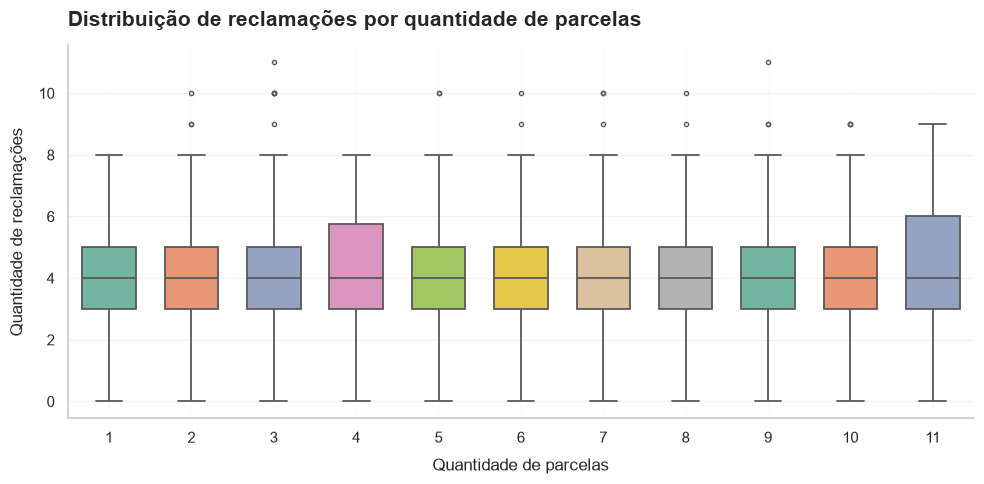

In [81]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="payment_installments",
    y_col="complaints_count",
    title="Distribuição de reclamações por quantidade de parcelas",
    x_label="Quantidade de parcelas",
    y_label="Quantidade de reclamações",
)

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


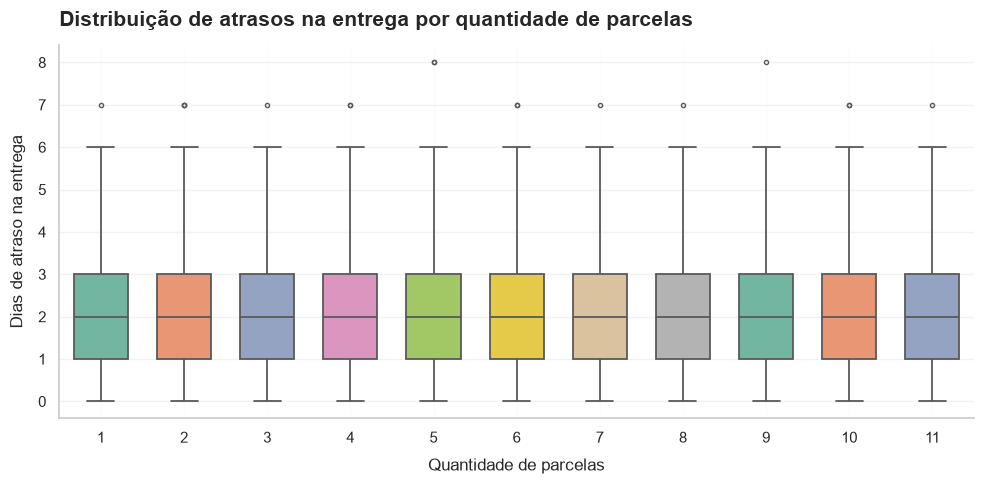

In [82]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="payment_installments",
    y_col="delivery_delay_days",
    title="Distribuição de atrasos na entrega por quantidade de parcelas",
    x_label="Quantidade de parcelas",
    y_label="Dias de atraso na entrega",
)

#### Conclusões da hipótese

Como observado nos boxplots, a quantidade de parcelas não mostra associação direta com as variáveis de comportamento de cliente (nps, reclamações) ou de logística (dias de atraso). Por isso, não temos evidência para sustentar a hipótese.

## Bloco 4: 
## 4. Perfil do cliente influencia NPS?

- **H14:** Clientes antigos sao mais tolerantes a falhas como atrasos ou várias tentativas de entrega.
- **H15:** Clientes novos tem NPS mais sensivel a primeira experiencia.
- **H16:** Idade e regiao podem revelar segmentos com expectativas diferentes

    -H16.1: Clientes mais jovens reagem de forma diferente a atrasos

    -H16.2: Clientes de regiões espcíficas são mais tolerantes a atraso?
- **H17:** Diferencas regionais podem refletir operacao logistica local.

### **H14:** Clientes antigos são mais tolerantes a falhas como atrasos

Para iniciar a análise, vamos considerar somente clientes com atraso no pedido, para que analisemos o impacto do tempo de fidelização em clientes com problema de atraso.

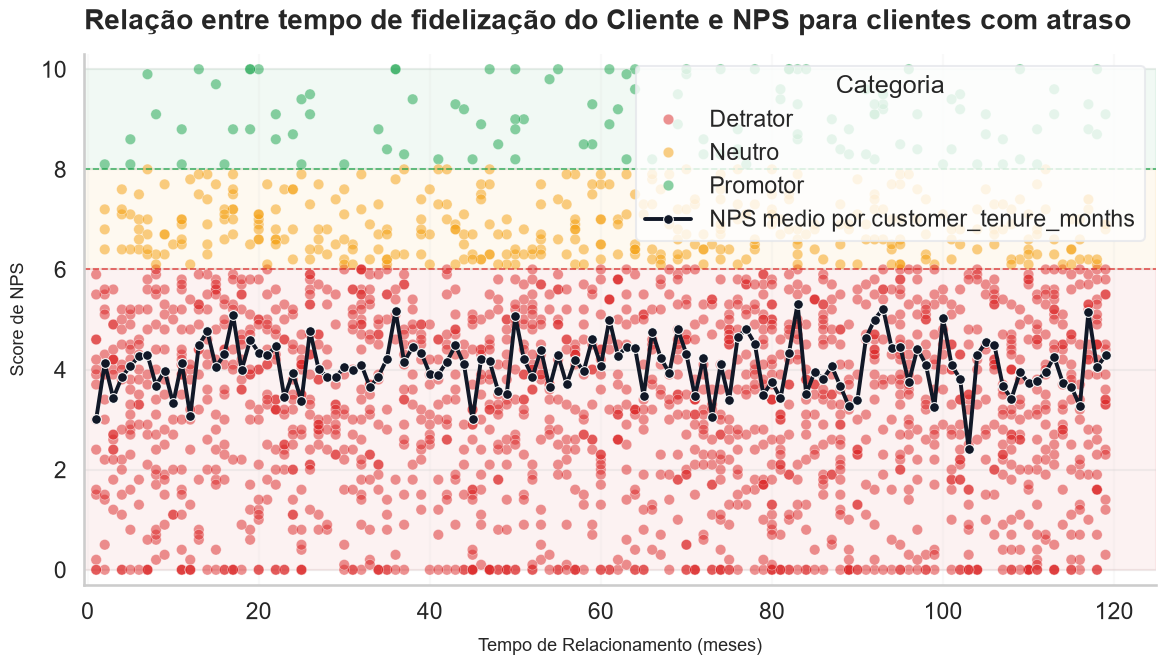

In [88]:
fig, ax = dv.plot_nps_relationship(
    df_delay,
    x_col="customer_tenure_months",
    y_col="nps_score",
    title="Relação entre tempo de fidelização do Cliente e NPS para clientes com atraso",
    x_label="Tempo de Relacionamento (meses)",
    y_label="Score de NPS",
)

Pelo gráfico de dispersão acima, não parece haver associação entre tempo de fidelizçaão do cliente e NPS quando existem falhas logísticas como atrasos.

### **H15:** Clientes novos tem NPS mais sensível

Essa hipótese sugere que clientes com maior tempo de relacionamento com a empresa tendem a ter um NPS mais alto. Isso pode indicar que a lealdade do cliente e a confiança na marca podem mitigar o impacto negativo de experiências de atraso, resultando em uma percepção mais positiva do serviço e maior probabilidade de recomendar a empresa a outros.

Por isso, vamos comparar o comportamento em média e mediana de NPS entre os quartis dos clientes por tempo de retenção.

In [90]:
df_tenure = df.copy()

df_tenure["faixa_fidelizacao"] = pd.qcut(
    df_tenure["customer_tenure_months"],
    q=4,
    labels=[
        "Q1 - menor tempo de retenção",
        "Q2",
        "Q3",
        "Q4 - maior tempo de retenção",
    ],
    duplicates="drop"
)

comparacao_fidelizacao = (
    df_tenure
    .groupby("faixa_fidelizacao", observed=True)
    .agg(
        qtd_pedidos=("order_id", "count"),
        reclamacoes_media=("complaints_count", "mean"),
        nps_medio=("nps_score", "mean"),
        nps_mediana=("nps_score", "median"),
    )
    .round(2)
)

comparacao_fidelizacao

,qtd_pedidos,reclamacoes_media,nps_medio,nps_mediana
faixa_fidelizacao,,,,
Q1 - menor tempo de retenção,627,4.15,4.41,4.4
Q2,628,4.21,4.40,4.5
Q3,633,4.06,4.37,4.4
Q4 - maior tempo de retenção,612,4.18,4.34,4.4


Não observou-se diferença significativa entre as médias e medianas nos quartis de clientes por tempo de retenção, não havendo, portanto, evidência para suportar a hipótese de que clientes mais novos tem comportamento diferente em relação à satisfação, a partir da métrica de NPS.

### **H16:** Idade e regiao podem revelar segmentos com expectativas diferentes

Primeiramente, vamos analisar somente se clientes de diferentes faixas etárias e diferentes regiões tem distribuições de NPS distintas

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


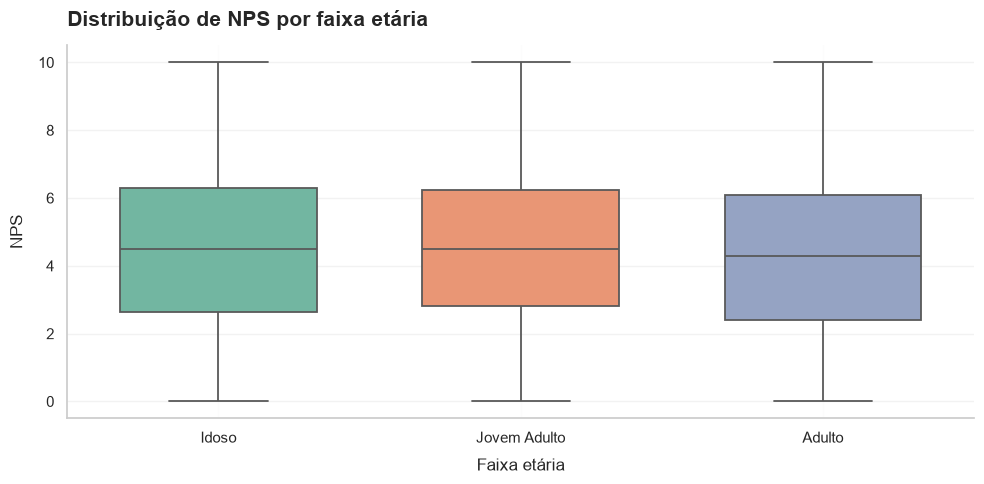

In [91]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="faixa_etaria",
    y_col="nps_score",
    title="Distribuição de NPS por faixa etária",
    x_label="Faixa etária",
    y_label="NPS",
)

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


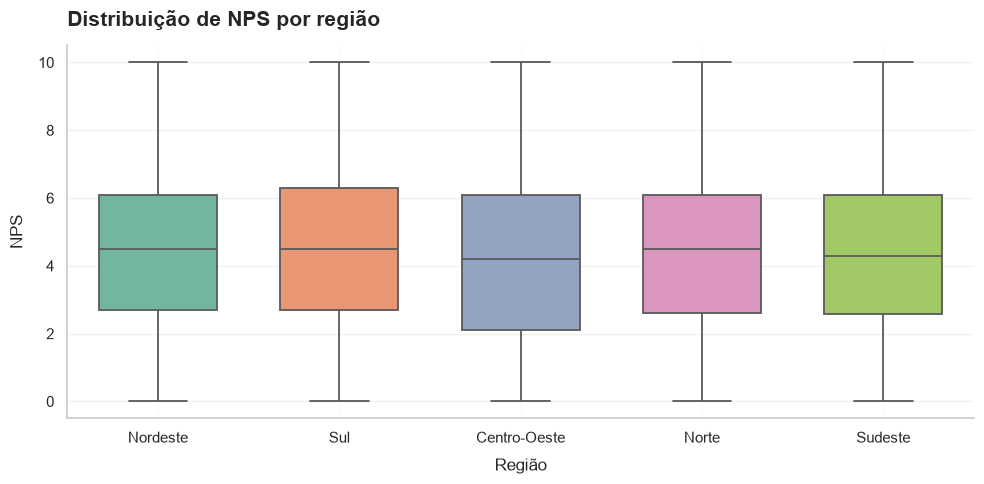

In [95]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="customer_region",
    y_col="nps_score",
    title="Distribuição de NPS por região",
    x_label="Região",
    y_label="NPS",
)

AS distribuições de NPS são similares entre os grupos analisados, tanto por região quanto por faixa etária. 

Para aprofundar um pouco mais nessa hipótese, podemos analisar se esses grupos se diferenciam quando há um evento de atraso, por exemplo. 

#### H16.1: Clientes mais jovens reagem de forma diferente a atrasos

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


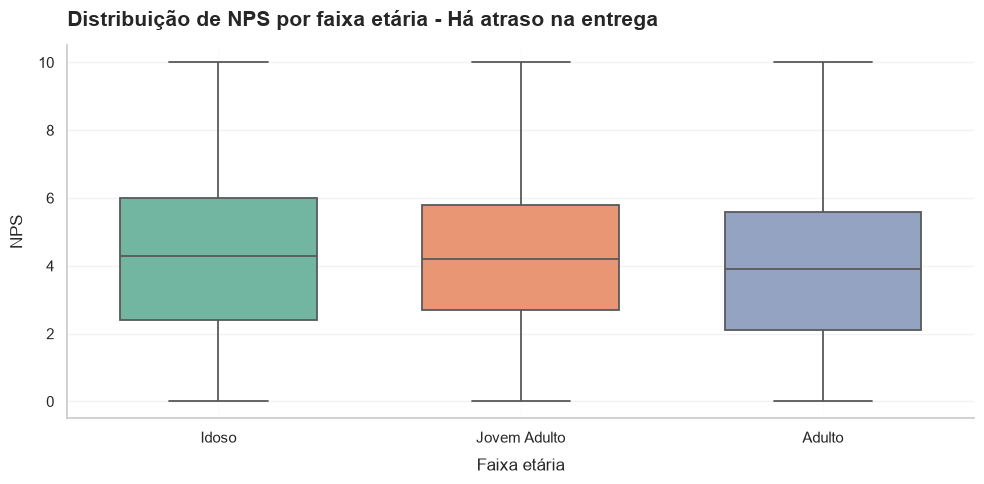

In [98]:
fig, ax = dv.plot_boxplot(
    df_delay,
    x_col="faixa_etaria",
    y_col="nps_score",
    title="Distribuição de NPS por faixa etária - Há atraso na entrega",
    x_label="Faixa etária",
    y_label="NPS",
)

#### H16.2: Clientes de regiões espcíficas são mais tolerantes a atraso?

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


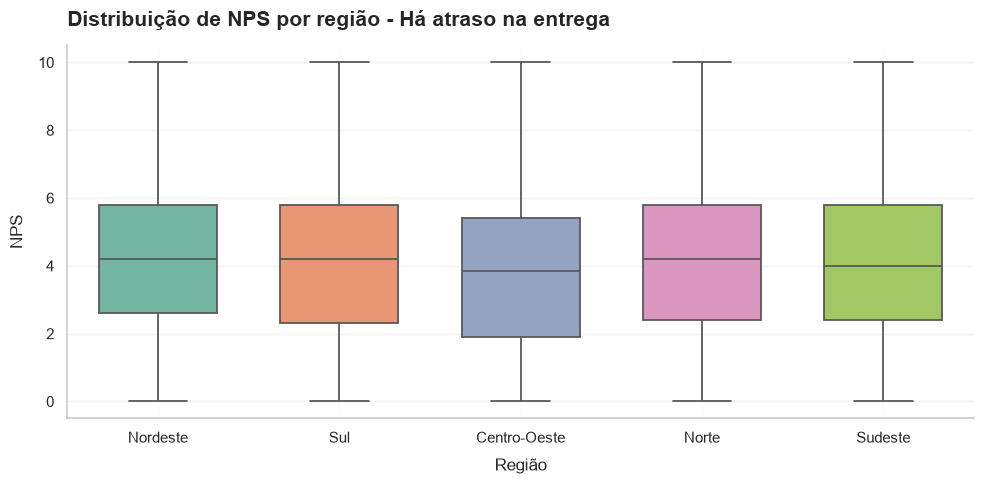

In [97]:
fig, ax = dv.plot_boxplot(
    df_delay,
    x_col="customer_region",
    y_col="nps_score",
    title="Distribuição de NPS por região - Há atraso na entrega",
    x_label="Região",
    y_label="NPS",
)

### **H17:** Diferenças regionais podem refletir operação logistica local.

Essa hipótese visa entender se existe diferença operacional no negócio entre diferentes regiões.
Para isso, podemos analisar a diferença entre regiões para as variáveis:
- `delivery_delay_days`
- `customer_service_contacts`
- `complaint_counts`
- `resolution_time_days`

Vamos fazer essa análise usando boxplots

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


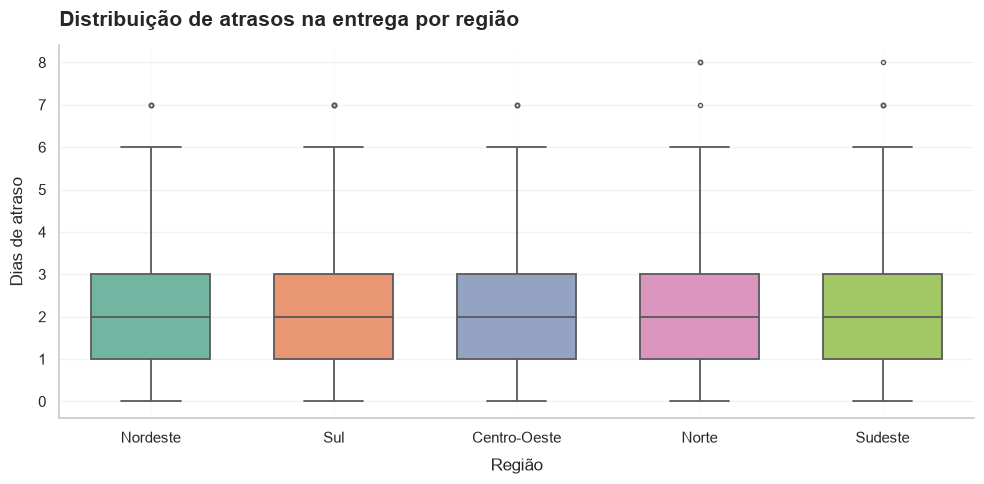

In [99]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="customer_region",
    y_col="delivery_delay_days",
    title="Distribuição de atrasos na entrega por região",
    x_label="Região",
    y_label="Dias de atraso",
)

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


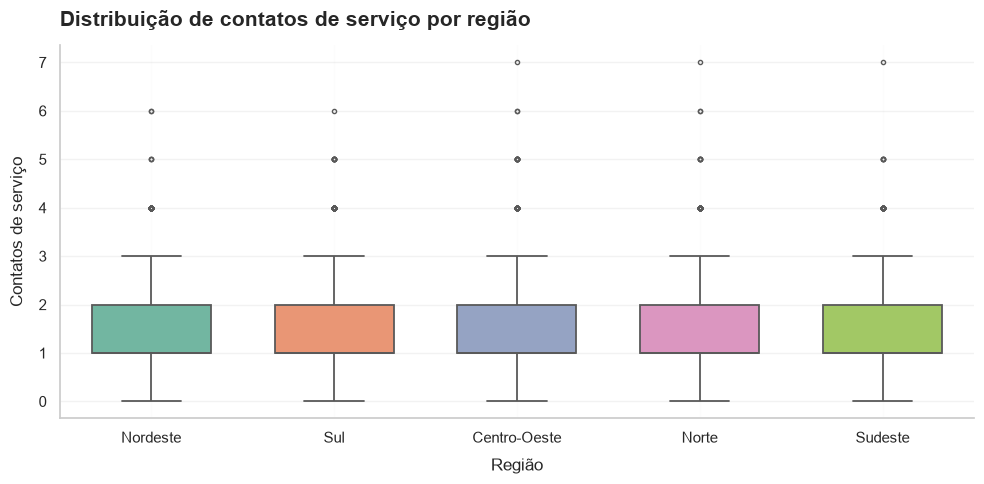

In [100]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="customer_region",
    y_col="customer_service_contacts",
    title="Distribuição de contatos de serviço por região",
    x_label="Região",
    y_label="Contatos de serviço",
)

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


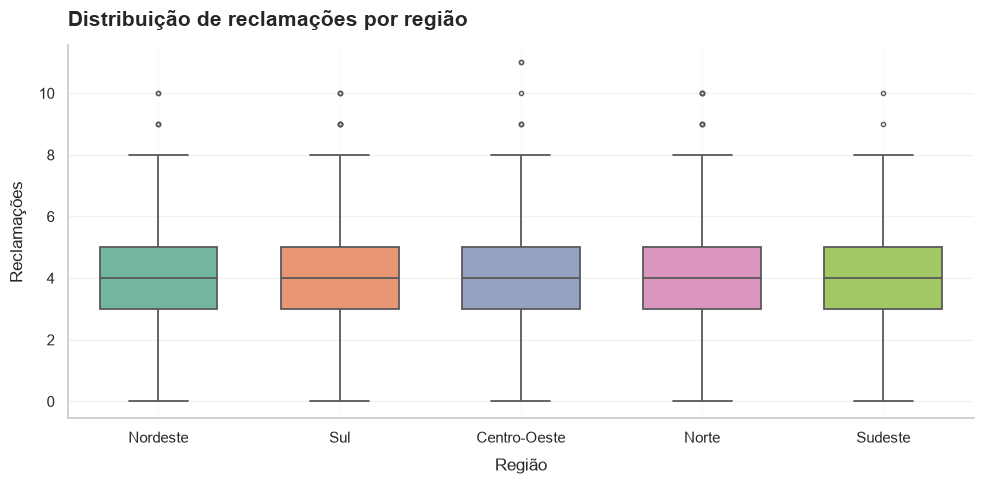

In [102]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="customer_region",
    y_col="complaints_count",
    title="Distribuição de reclamações por região",
    x_label="Região",
    y_label="Reclamações",
)

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


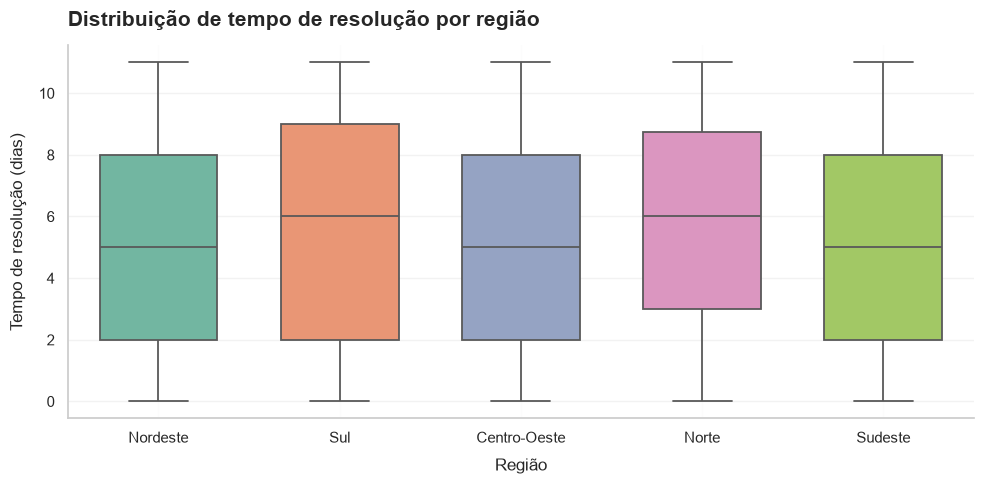

In [103]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="customer_region",
    y_col="resolution_time_days",
    title="Distribuição de tempo de resolução por região",
    x_label="Região",
    y_label="Tempo de resolução (dias)",
)

#### Conclusões da hipótese

Para a maior parte das variáveis analisadas, não notou-se diferença de distribuição entre as regiões. 

A única dimensão que apresentou maior variabilidade foi o tempo de resolutividade, que apresentou um ligeiro aumento nas regiões Norte e Sul. Possivelmente isso mostra que existe uma dificuldade operacional um pouco maior de resolver problemas em regiões na extremidado do país. 

## Bloco 5

## Indicadores internos se relacionam com NPS?
Análises que ajudam a analisar o histórico, mas não necessariamente podem ser usadas como features em modelo preditivo.

- **H18:** Recompra em 30 dias valida satisfação real.
- **H19:** Ausência de recompra pode ser consequência de expriência ruim.

### **H18:** Recompra em 30 dias valida satisfação real.


Para analisar essa hipótese, vamos verificar se há diferença na métrica de satisfação entre clientes que efetuaram recompra. Isso tem o objetivo de entender o quanto a recompra pode ser usada como indicador de satisfação, junto ao NPS.

c:\Users\ArturCosta\personalRepos\tech-challenge-fase-1\src\utils\data_viz.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


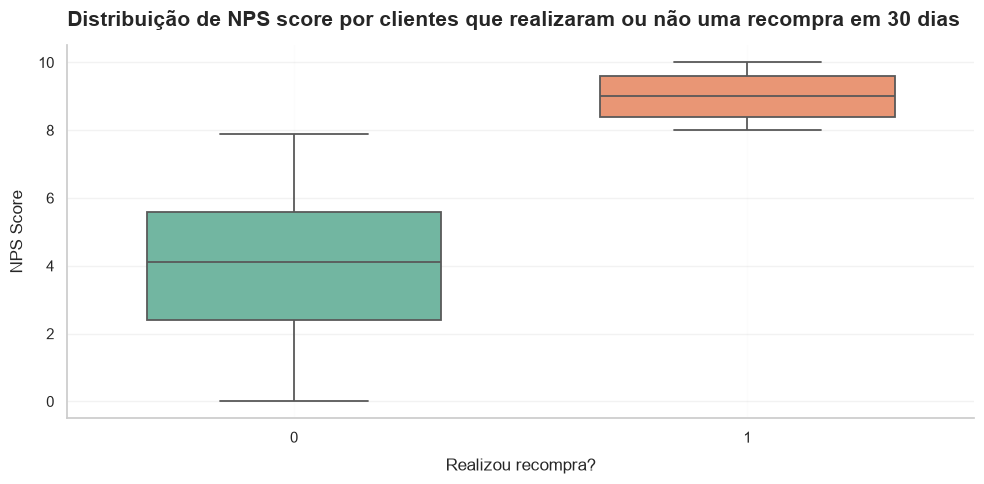

In [105]:
fig, ax = dv.plot_boxplot(
    df,
    x_col="repeat_purchase_30d",
    y_col="nps_score",
    title="Distribuição de NPS score por clientes que realizaram ou não uma recompra em 30 dias",
    x_label="Realizou recompra?",
    y_label="NPS Score",
)

A diferença na distribuição de NPS demonstra que a realização de recompra valida satisfação. Vamos metrificar isso em termos de diferenças em média de NPS e quantidade de promotores percentual.

In [106]:
comparacao_recompra = (
    df
    .groupby("repeat_purchase_30d")
    .agg(
        qtd_pedidos=("order_id", "count"),
        nps_medio=("nps_score", "mean"),
        nps_mediano=("nps_score", "median"),
        pct_promotores=("classificacao", lambda s: (s == "Promotor").mean() * 100),
        pct_neutros=("classificacao", lambda s: (s == "Neutro").mean() * 100),
        pct_detratores=("classificacao", lambda s: (s == "Detrator").mean() * 100),
    )
    .round(2)
    .rename(index={
        0: "Sem recompra em 30 dias",
        1: "Com recompra em 30 dias",
    })
)

comparacao_recompra

,qtd_pedidos,nps_medio,nps_mediano,pct_promotores,pct_neutros,pct_detratores
repeat_purchase_30d,,,,,,
Sem recompra em 30 dias,2282,3.94,4.1,0.0,18.89,74.19
Com recompra em 30 dias,218,9.01,9.0,92.2,7.80,0.00


#### Conclusões da hipótese

É bem claro que a recompra é uma variável interessante, pois praticamente todos os promotores (92,2%) efetuaram recompra dentro de 30 dias. A diferença em média de NPS também corrobora com a hipótese: 9,01 para clientes com recompra e 3,94 para clientes sem recompra.

Porém, é importante ter cuidado com essa variável, pois ela é uma variável posterior à primeira compra do cliente, e pode, portanto, introduzir vazamento de dados ao ser utilizada em modelos de regressão do NPS, por exemplo. 


### **H19:** Ausência de recompra pode ser consequência de experiência ruim.

Para verificar essa hipótese de forma simplificada, vamos ver se no grupo de clientes que não efetuaram recompra, a quantidade de dias de atraso médio é significativamente maior que dos clientes com recompra. 

In [107]:
comparacao_recompra = (
    df
    .groupby("repeat_purchase_30d")
    .agg(
        qtd_pedidos=("order_id", "count"),
        nps_medio=("nps_score", "mean"),
        nps_mediano=("nps_score", "median"),
        qtd_dias_atraso_medio=("delivery_delay_days", "mean"),
        qtd_dias_atraso_mediana=("delivery_delay_days", "median"),
        pct_promotores=("classificacao", lambda s: (s == "Promotor").mean() * 100),
        pct_neutros=("classificacao", lambda s: (s == "Neutro").mean() * 100),
        pct_detratores=("classificacao", lambda s: (s == "Detrator").mean() * 100),
    )
    .round(2)
    .rename(index={
        0: "Sem recompra em 30 dias",
        1: "Com recompra em 30 dias",
    })
)

comparacao_recompra

,qtd_pedidos,nps_medio,nps_mediano,qtd_dias_atraso_medio,qtd_dias_atraso_mediana,pct_promotores,pct_neutros,pct_detratores
repeat_purchase_30d,,,,,,,,
Sem recompra em 30 dias,2282,3.94,4.1,2.32,2.0,0.0,18.89,74.19
Com recompra em 30 dias,218,9.01,9.0,0.76,1.0,92.2,7.80,0.00


#### Conclusões da hipótese

Temos evidência para sustentar a H19, pois, em média, clientes sem recompra tiveram mais de 2 dias de atraso (2,32) , enquanto clientes com recompra tiveram em média menos de um dia de atraso (0,76). Além disso, a diferença de NPS observada em H18 corrobora também com a afirmação.

### **H20:** Os indicadores internos de satisfação tem coerência com NPS.

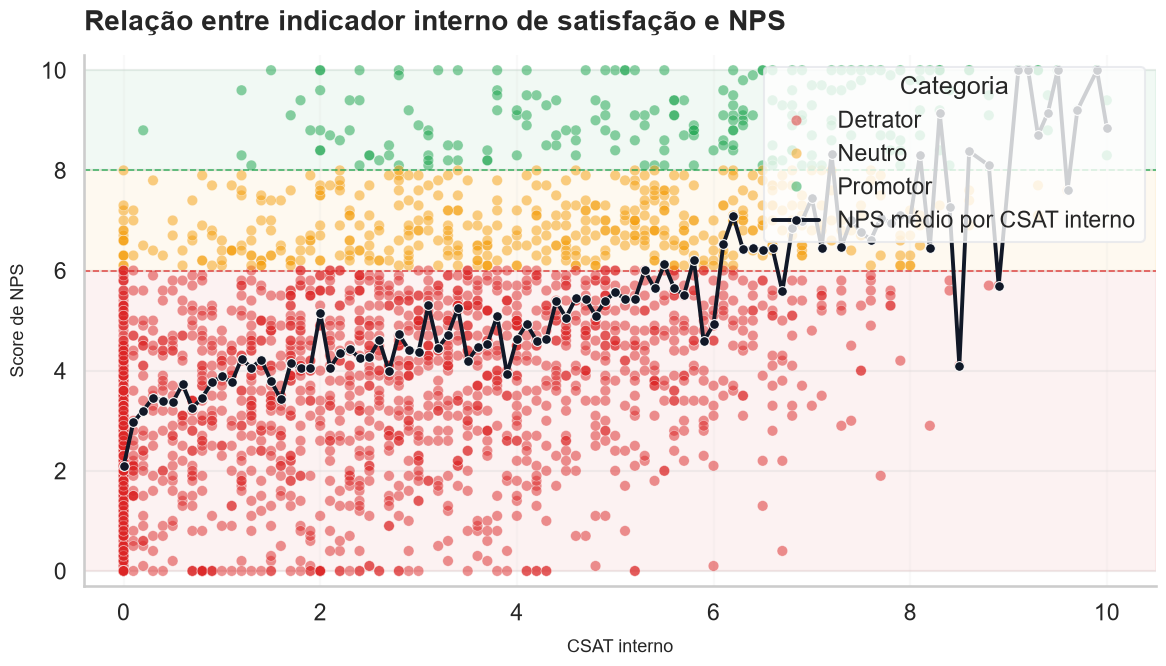

In [113]:
fig, ax = dv.plot_nps_relationship(df,
    x_col="csat_internal_score",
    y_col="nps_score",
    title="Relação entre indicador interno de satisfação e NPS",
    x_label="CSAT interno",
    y_label="Score de NPS",
    mean_line_label="NPS médio por CSAT interno"
)

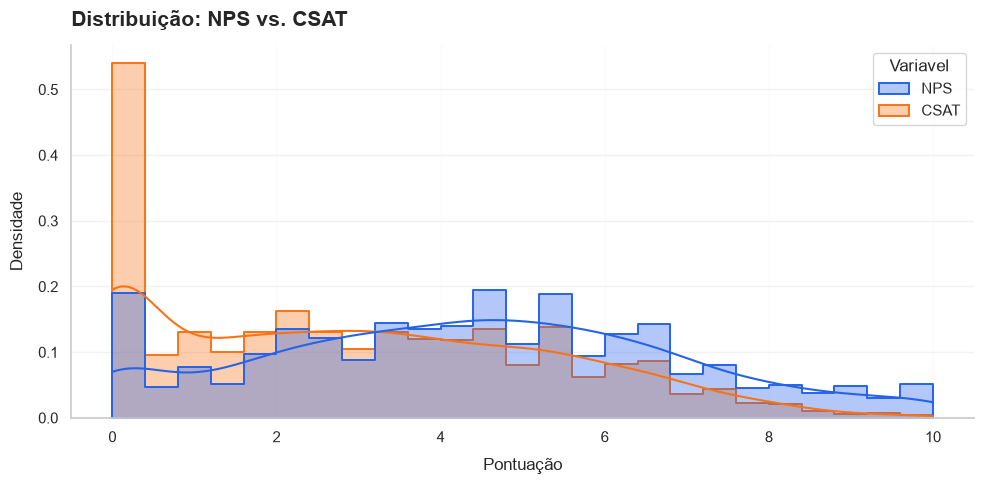

In [117]:
fig, ax = dv.plot_two_column_histograms(
    df,
    first_col="nps_score",
    second_col="csat_internal_score",
    first_label="NPS",
    second_label="CSAT",
    title="Distribuição: NPS vs. CSAT",
    x_label="Pontuação",
    bins=25,
)

In [118]:
df[["nps_score", "csat_internal_score"]].corr(method = 'pearson')

,nps_score,csat_internal_score
nps_score,1.000000,0.563952
csat_internal_score,0.563952,1.000000


In [120]:
df[["nps_score", "csat_internal_score"]].describe()

,nps_score,csat_internal_score
count,2500.000000,2500.000000
mean,4.378600,2.941600
std,2.510229,2.378957
min,0.000000,0.000000
25%,2.600000,0.700000
50%,4.400000,2.800000
75%,6.100000,4.800000
max,10.000000,10.000000


#### Conclusões da hipótese

O indicador de satisfação interno é correlacionado com o NPS. No entanto, nota-se que a distribuição do indicador interno é deslocada à esquerda, principalmente devido a um alto volume de notas 0, o que é evidenciado na comparação dos histogramas das 2 variáveis. 

Isso faz com que tanto a média quanto a mediana do indicador interno sejam inferiores às de NPS, conforme mostrado nas estatísticas descritivas acima. 

Essa diferença pode ser um indicativo negocial de que o método usado para pontuar a satisfação de um cliente pela empresa é mais rígido do que o NPS, nota atribuída pelo próprio cliente à empresa. Isso é um **insight relevante** para que os times de estratégia e customer experience analisem se de fato isso se adequa à visão da empresa e se esse comportamento é esperado, ou se são necessárias correções nesse indicador.

Pensando em um modelo de regressão para o NPS (ou classificação entre detratores, neutros e promotores), é importante entender o **contexto negocial desse indicador** e em qual momento da jornada do cliente ele é calculado, pois, a depender disso, pode ser introduzido data leakage no modelo, se ele for um indicador posterior ao processo de atribuição do NPS, por exemplo. 